# MasterControl - Lead Scoring & Conversion Optimization
### A Visual Report on Feature Engineering, Model Selection & Business Impact
**Authors:** Thomas Beck, Max Ridgeway, Astha KC  
**Date:** Spring 2026  
**Course:** MSBA Capstone

---

## Table of Contents

1. [Introduction](#introduction)
2. [Data Preparation & Feature Engineering](#data-preparation--feature-engineering)
3. [Exploratory Data Analysis](#understanding-the-data-at-a-glance)
4. [Model Analysis](#model-analysis)
5. [Stacking & Voting Ensembles](#stacking--voting-ensembles)
6. [Ablation Studies](#ablation-studies)
7. [Test Set Evaluation](#test-set-evaluation)
8. [SHAP Explainability](#shap-explainability)
9. [Profit Analysis](#profit-analysis)
10. [Sponsor Q&A Validation](#sponsor-qa-validation)
11. [Conclusion & Business Recommendations](#conclusion)
12. [Group Members & Contributions](#group-members--contributions)

## Introduction

### Business Problem

MasterControl sells quality management software (QMS) to regulated industries - primarily life sciences and manufacturing. 
Their sales pipeline converts Marketing Qualified Leads (MQLs) into Sales Qualified Leads (SQLs) through a Business Development Representative (BDR) qualification step. 
The core business problem: **conversion rates differ significantly between product lines** - the flagship Mx (Manufacturing Excellence) product converts at ~18% while the newer Qx (Quality Excellence) product converts at only ~15%. 
MasterControl needs to understand *which leads are most likely to convert* and *what characteristics drive conversion* so BDRs can prioritize high-value prospects and marketing can optimize channel spend.

### Analytic Problem

We frame this as a **binary classification task**: predict whether a QAL (Qualified Activity Lead) will convert to SQL (1) or not (0). 
The dataset contains 16,816 CRM records with demographic, firmographic, behavioral, and channel-source features. 
Key analytic challenges include:
- **Class imbalance** (~17% positive rate) requiring SMOTE and careful metric selection
- **High-cardinality categoricals** (job titles, industries) requiring target encoding
- **Feature engineering** to capture domain-specific signals (seniority, role-product alignment, capital density)
- **Model interpretability** requirements - the sponsor needs actionable insights, not just predictions
- **Profit optimization** - translating model scores into dollar-value prioritization ($6K per SQL vs $50 per call)

We evaluate five base learners (CatBoost, XGBoost, LightGBM, GradientBoosting, RandomForest), two ensemble methods (Stacking, Voting), 
and select a champion model based on AUC-ROC, calibration, and business profit curves.

### Methodology

We follow the **CRISP-DM** framework:
1. **Business Understanding** - Sponsor interviews, Q&A validation
2. **Data Understanding** - EDA, distribution analysis, correlation
3. **Data Preparation** - Cleaning, feature engineering, encoding, SMOTE
4. **Modeling** - 5 base models + 2 ensembles, 150-iteration RandomizedSearchCV
5. **Evaluation** - AUC-ROC, calibration, SHAP, profit curves
6. **Deployment** - Scored lead list, business recommendations

In [1]:
# ── Setup: core imports, warnings suppression, parallelism config ──

import subprocess, sys, warnings, time, re, multiprocessing
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
np.random.seed(42)
START_TIME = time.time()

# Reserve 2 cores for other tasks
N_JOBS = max(1, multiprocessing.cpu_count() - 2)

In [2]:
# ── Dependency installer: auto-install missing packages via pip ──


def install_if_missing(package_name, import_name=None, pip_name=None):
    import_name = import_name or package_name.lower()
    pip_name = pip_name or import_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pip_name, "-q"],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )


for pkg in [
    ("scikit-learn", "sklearn", "scikit-learn"),
    ("pyprojroot", None, None),
    ("CatBoost", "catboost", None),
    ("XGBoost", "xgboost", None),
    ("LightGBM", "lightgbm", None),
    ("SHAP", "shap", None),
    ("matplotlib", None, None),
    ("seaborn", None, None),
    ("tabulate", None, None),
    ("imbalanced-learn", "imblearn", "imbalanced-learn"),
]:
    install_if_missing(*pkg)

In [3]:
# ── Library imports: sklearn, boosting, SMOTE, plotting, SHAP ──

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from pyprojroot import here
from types import SimpleNamespace
from tabulate import tabulate

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    FunctionTransformer,
    OrdinalEncoder,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
    ClassifierMixin,
    clone,
)
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix,
    brier_score_loss,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression

SMOTE_AVAILABLE = False
try:
    from imblearn.over_sampling import SMOTE

    SMOTE_AVAILABLE = True
except ImportError:
    pass

In [4]:
# ── Global configuration: random seed, CV folds, color palette, helpers ──

RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER_SEARCH = 150
TEST_SIZE = 0.10
VAL_SIZE = 0.10

LSA_COMPONENTS = 20
TFIDF_MAX_FEATURES = 500

COST_PER_CALL = 50
VALUE_PER_SQL = 6000

SHAP_BACKGROUND_SAMPLES = 100
SHAP_TEST_SAMPLES = 200

COL_SUCCESS = "#00534B"
COL_RISK = "#F05627"
COL_NEUTRAL = "#95a5a6"
COL_ACCENT = "#2980b9"
COL_GOLD = "#f39c12"
COL_PROFIT = "#27ae60"
COL_LOWVAL = "#e74c3c"
COL_PREMIUM = "#2ecc71"

MODEL_COLORS = {
    "CatBoost": "#1b9e77",
    "XGBoost": "#d95f02",
    "LightGBM": "#7570b3",
    "GradientBoosting": "#e7298a",
    "RandomForest": "#66a61e",
    "StackingEnsemble": "#00534B",
    "VotingEnsemble": "#e6ab02",
}

# PDF-friendly defaults
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update(
    {
        "figure.figsize": (7.5, 4.5),
        "figure.dpi": 200,
        "axes.titleweight": "bold",
        "font.family": "sans-serif",
        "figure.autolayout": True,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.1,
    }
)


def print_table(data, caption="", fmt="pipe"):
    if isinstance(data, pd.DataFrame):
        print(f"\n**{caption}**\n" if caption else "")
        print(data.to_markdown(index=False))
    else:
        print(data)


DATA_DIR = here("data")
OUTPUT_DIR = here("output")
CLEANED_DATA_PATH = here("output/Cleaned_QAL_Performance_for_MSBA.csv")
RAW_DATA_PATH = here("data/QAL Performance for MSBA.csv")
DATA_PATH = CLEANED_DATA_PATH if CLEANED_DATA_PATH.exists() else RAW_DATA_PATH

In [5]:
# ── CatBoost sklearn wrapper + availability checks for optional libs ──

CATBOOST_AVAILABLE = False
try:
    from catboost import CatBoostClassifier as CatBoostRaw

    class SklearnCatBoost(BaseEstimator, ClassifierMixin):
        _estimator_type = "classifier"

        def __init__(
            self,
            iterations=500,
            depth=6,
            learning_rate=0.1,
            l2_leaf_reg=3,
            border_count=64,
            random_state=42,
            verbose=0,
            thread_count=1,
        ):
            self.iterations = iterations
            self.depth = depth
            self.learning_rate = learning_rate
            self.l2_leaf_reg = l2_leaf_reg
            self.border_count = border_count
            self.random_state = random_state
            self.verbose = verbose
            self.thread_count = thread_count
            self._model = None

        def __sklearn_tags__(self):
            tags = SimpleNamespace()
            tags.estimator_type = "classifier"
            tags.classifier_tags = SimpleNamespace()
            tags.regressor_tags = None
            tags.transformer_tags = None
            tags.input_tags = SimpleNamespace(
                allow_nan=True,
                pairwise=False,
                one_d_labels=True,
                two_d_labels=False,
            )
            tags.target_tags = SimpleNamespace(
                required_y=True,
                one_d_labels=True,
                two_d_labels=False,
            )
            return tags

        def fit(self, X, y, **kw):
            self._model = CatBoostRaw(
                iterations=self.iterations,
                depth=self.depth,
                learning_rate=self.learning_rate,
                l2_leaf_reg=self.l2_leaf_reg,
                border_count=self.border_count,
                random_state=self.random_state,
                verbose=self.verbose,
                thread_count=self.thread_count,
                allow_writing_files=False,
            )
            self._model.fit(X, y, **kw)
            self.classes_ = np.unique(y)
            return self

        def predict(self, X):
            return self._model.predict(X).flatten().astype(int)

        def predict_proba(self, X):
            return self._model.predict_proba(X)

        @property
        def feature_importances_(self):
            return self._model.get_feature_importance()

    CATBOOST_AVAILABLE = True
except ImportError:
    pass

XGBOOST_AVAILABLE = False
try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True
except ImportError:
    pass

LIGHTGBM_AVAILABLE = False
try:
    from lightgbm import LGBMClassifier

    LIGHTGBM_AVAILABLE = True
except ImportError:
    pass

TARGET_ENCODER_AVAILABLE = False
try:
    from sklearn.preprocessing import TargetEncoder

    TARGET_ENCODER_AVAILABLE = True
except ImportError:
    pass

SHAP_AVAILABLE = False
try:
    import shap

    SHAP_AVAILABLE = True
except ImportError:
    pass

In [6]:
# ── Feature engineering lookup tables: intent, channel, industry, role maps ──

INTENT_STRENGTH_MAP = {
    "P1 - Website Pricing": 5,
    "P1 - Contact Us": 5,
    "P1 - Video Demo": 3,
    "P1 - Live Demo": 3,
    "P1 - Webinar Demo": 1,
    "No Priority": 1,
    "Priority 1": 2,
    "Priority 2": 0,
}

CHANNEL_TIER_MAP = {
    "Direct/Inbound": "Premium",
    "SEO": "Premium",
    "Referrals": "Premium",
    "Online Ads": "Standard",
    "Directory Listing": "Standard",
    "Events": "Standard",
    "Outbound Prospecting": "Standard",
    "Email": "Low-Value",
    "External Demand Gen": "Low-Value",
}
CHANNEL_NUMERIC_MAP = {
    "Premium": 3,
    "Standard": 2,
    "Low-Value": 1,
    "Unknown": 2,
}

INDUSTRY_BUDGET_MULTIPLIER = {
    "Pharma & BioTech": 3.0,
    "Blood & Biologics": 2.5,
    "Medical Device": 2.0,
    "Non-Life Science": 1.0,
    "Consumer Packaged Goods": 0.8,
}
TIER_SIZE_MAP = {
    "Small": 50,
    "Medium": 500,
    "Large": 5000,
}

PRODUCT_ROLE_ALIGNMENT = {
    "Mx": ["Op", "Mfg", "Manuf", "Production", "Plant"],
    "Qx": ["Qual", "QA", "QC", "Compliance", "Validation"],
}

HIGH_VALUE_BIGRAMS = [
    "continuous improvement",
    "document control",
    "process engineer",
    "quality systems",
    "regulatory affairs",
    "quality assurance",
    "validation engineer",
    "compliance manager",
]

# Ordinal maps for proper rank encoding
SENIORITY_ORDER = [
    "Unknown",
    "Other",
    "IC",
    "Manager",
    "Director",
    "VP",
    "SVP",
    "C-Suite",
]
SCOPE_ORDER = ["Standard", "Site", "Regional", "Global"]

## Data Preparation & Feature Engineering

### Raw Data

The raw CRM export (`QAL Performance for MSBA.csv`) contains **16,816 QAL records** with the following attribute groups:
- **Account attributes**: industry, employee tier, territory/region, manufacturing model
- **Contact attributes**: job title, functional area, seniority level
- **Behavioral attributes**: lead source/channel, priority assignment, activity timestamps
- **Target variable**: `Converted` (1 = QAL converted to SQL, 0 = did not convert)

### Cleaning Steps

1. **Missing values**: Categorical NAs filled with `"Unknown"`; no numeric imputation needed
2. **Date parsing**: `QAL Created Date` converted to datetime; `days_since_created` computed as temporal decay feature
3. **Title normalization**: Raw job titles cleaned (lowercase, stripped punctuation) then parsed for seniority and function keywords
4. **Deduplication**: Checked for duplicate lead IDs (none found in this export)

### Engineered Features (20+ new columns)

| Feature | Logic | Rationale |
|---------|-------|----------|
| `intent_strength` | Map lead source to 0-5 intent score | Direct requests > webinar views > cold lists |
| `channel_efficiency_tier` | Bin channels into High/Mid/Low conversion tiers | Reduces cardinality while preserving signal |
| `capital_density_score` | log(employees) x industry budget multiplier | Pharma/Bio at 200 employees > General Mfg at 2000 |
| `role_product_match` | Cross-reference job function x product line | Quality roles align with Qx; Ops roles align with Mx |
| `seniority_rank` | Ordinal encoding: VP=5, Director=4, Manager=3... | Captures decision-making authority gradient |
| `temporal_decay` | Exponential decay on days since QAL creation | Recent leads have higher conversion probability |
| `hidden_gem_flag` | Low-tier channel + high-intent + mid-size company | Identifies undervalued leads from weak channels |
| `golden_segment` | Mid-size + regulated industry + senior title | Highest-converting demographic intersection |
| Interaction terms | `seniority x industry`, `seniority x model`, `power_trio` | Capture non-linear feature combinations |
| TF-IDF + LSA | 500 TF-IDF features -> 20 SVD components on job titles | Extract latent semantic signals from free-text titles |

### Encoding & Balancing

- **Target encoding** (with smoothing) for high-cardinality categoricals (industry, territory, channel)
- **Label encoding** for low-cardinality ordinals (product line, tier)
- **SMOTE** oversampling applied to training set only (prevents data leakage into val/test)
- **Train/Val/Test split**: 80/10/10 stratified by target, with text data split aligned

In [7]:
# ── Data pipeline: clean raw CRM data + engineer 20+ predictive features ──


def clean_and_engineer(filepath):
    df = pd.read_csv(filepath)
    df.columns = [
        c.strip().lower().replace(" ", "_").replace("/", "_").replace("-", "_")
        for c in df.columns
    ]

    # --- Target ---
    if "is_success" not in df.columns:
        df["is_success"] = df["next_stage__c"].isin(["SQL", "SQO", "Won"]).astype(int)

    # --- Feature 1: Intent Strength ---
    if "priority" in df.columns:
        df["intent_strength"] = df["priority"].map(INTENT_STRENGTH_MAP).fillna(1)
    else:
        df["intent_strength"] = 1

    # --- Feature 2: Channel Efficiency ---
    ch_col = (
        "last_tactic_campaign_channel"
        if "last_tactic_campaign_channel" in df.columns
        else "lead_source"
    )
    if ch_col in df.columns:
        df["channel_tier"] = df[ch_col].map(CHANNEL_TIER_MAP).fillna("Standard")
        df["channel_efficiency"] = df["channel_tier"].map(CHANNEL_NUMERIC_MAP)
    else:
        df["channel_tier"] = "Standard"
        df["channel_efficiency"] = 2

    # --- Feature 3: Hidden Gem Flag ---
    m_col = (
        "acct_manufacturing_model" if "acct_manufacturing_model" in df.columns else None
    )
    i_col = "acct_target_industry" if "acct_target_industry" in df.columns else None
    s_col = (
        "acct_primary_site_function"
        if "acct_primary_site_function" in df.columns
        else None
    )
    gem = pd.Series(False, index=df.index)
    if m_col:
        gem |= df[m_col].str.contains("Not Enough Info", case=False, na=False)
    if s_col:
        gem |= df[s_col].str.contains("Non-manufacturing", case=False, na=False)
    if i_col:
        gem |= df[i_col].str.contains("Non-manufacturing", case=False, na=False)
    df["is_hidden_gem"] = gem.astype(int)

    # --- Feature 4: Capital Density Score ---
    t_col = "acct_tier_rollup" if "acct_tier_rollup" in df.columns else None
    if i_col and t_col:
        df["_ind_mult"] = df[i_col].map(
            lambda x: next(
                (
                    v
                    for k, v in INDUSTRY_BUDGET_MULTIPLIER.items()
                    if k.lower() in str(x).lower()
                ),
                1.0,
            )
        )
        df["_tier_size"] = df[t_col].map(TIER_SIZE_MAP).fillna(500)
        df["capital_density_score"] = df["_ind_mult"] * df["_tier_size"]
        df["capital_density_log"] = np.log1p(df["capital_density_score"])
        df.drop(
            columns=["_ind_mult", "_tier_size", "capital_density_score"],
            errors="ignore",
            inplace=True,
        )
    else:
        df["capital_density_log"] = np.log1p(500)

    # --- Feature 5: Role-Product Match (continuous) ---
    title_col = "contact_lead_title" if "contact_lead_title" in df.columns else None
    p_col = "product_segment" if "product_segment" in df.columns else "solution_rollup"
    if "product_segment" not in df.columns:
        df["product_segment"] = df["solution_rollup"].apply(
            lambda s: (
                "Mx" if str(s) == "Mx" else ("Qx" if str(s) == "Qx" else "Other")
            )
        )
    if title_col and p_col in df.columns:

        def _role_match(row):
            title = str(row[title_col]).lower() if pd.notna(row[title_col]) else ""
            product = str(row[p_col]) if pd.notna(row[p_col]) else ""
            if product in PRODUCT_ROLE_ALIGNMENT:
                hits = sum(
                    1 for kw in PRODUCT_ROLE_ALIGNMENT[product] if kw.lower() in title
                )
                return hits
            return 0

        df["role_product_match"] = df.apply(_role_match, axis=1)
    else:
        df["role_product_match"] = 0

    # --- Feature 6: Title Bigrams ---
    if title_col and title_col in df.columns:
        for bigram in HIGH_VALUE_BIGRAMS:
            col_name = "has_" + bigram.replace(" ", "_")
            df[col_name] = (
                df[title_col].str.lower().str.contains(bigram, na=False).astype(int)
            )
        bg_cols = [c for c in df.columns if c.startswith("has_")]
        df["title_bigram_count"] = df[bg_cols].sum(axis=1)
    else:
        df["title_bigram_count"] = 0

    # --- Title Parsing ---
    if "title_seniority" not in df.columns and title_col and title_col in df.columns:

        def _seniority(t):
            if pd.isna(t):
                return "Unknown"
            t = str(t).lower()
            if re.search(r"\b(ceo|cfo|coo|cto|cio|chief|" r"c-level|president)\b", t):
                return "C-Suite"
            if re.search(r"\b(svp|senior vice president|evp)\b", t):
                return "SVP"
            if re.search(r"\b(vp|vice president)\b", t):
                return "VP"
            if re.search(r"\b(director|head of)\b", t):
                return "Director"
            if re.search(r"\b(manager|mgr|supervisor|lead)\b", t):
                return "Manager"
            if re.search(
                r"\b(analyst|engineer|specialist|" r"associate|coordinator)\b", t
            ):
                return "IC"
            return "Other"

        def _function(t):
            if pd.isna(t):
                return "Unknown"
            t = str(t).lower()
            if re.search(r"\b(quality|qa|qc|qms|compliance|" r"validation|capa)\b", t):
                return "Quality"
            if re.search(r"\b(regulatory|reg affairs|" r"submissions)\b", t):
                return "Regulatory"
            if re.search(
                r"\b(manufacturing|production|" r"operations|ops|plant|supply)\b", t
            ):
                return "Mfg/Ops"
            if re.search(r"\b(it|information tech|software|" r"systems|data)\b", t):
                return "IT"
            if re.search(
                r"\b(r&d|research|development|" r"scientist|clinical|lab)\b", t
            ):
                return "R&D"
            if re.search(r"\b(project|program|pmo)\b", t):
                return "PMO"
            return "Other"

        def _scope(t):
            if pd.isna(t):
                return "Standard"
            t = str(t).lower()
            if re.search(
                r"\b(global|worldwide|international|" r"corporate|enterprise)\b", t
            ):
                return "Global"
            if re.search(r"\b(regional|division|group)\b", t):
                return "Regional"
            if re.search(r"\b(site|plant|facility|local)\b", t):
                return "Site"
            return "Standard"

        df["title_seniority"] = df[title_col].apply(_seniority)
        df["title_function"] = df[title_col].apply(_function)
        df["title_scope"] = df[title_col].apply(_scope)

    # --- NEW: Ordinal seniority & scope encoding ---
    if "title_seniority" in df.columns:
        sen_map = {v: i for i, v in enumerate(SENIORITY_ORDER)}
        df["seniority_rank"] = df["title_seniority"].map(sen_map).fillna(0)
    if "title_scope" in df.columns:
        sco_map = {v: i for i, v in enumerate(SCOPE_ORDER)}
        df["scope_rank"] = df["title_scope"].map(sco_map).fillna(0)

    # --- Decision maker ---
    if "is_decision_maker" not in df.columns:
        df["is_decision_maker"] = (
            df["title_seniority"].isin(["C-Suite", "SVP", "VP", "Director"]).astype(int)
        )

    # --- Title specificity (word count) ---
    if title_col and title_col in df.columns:
        df["title_word_count"] = (
            df[title_col].fillna("").apply(lambda x: len(str(x).split()))
        )

    # --- Temporal features ---
    if "cohort_date" in df.columns or "qal_cohort_date" in df.columns:
        cohort_src = (
            "qal_cohort_date" if "qal_cohort_date" in df.columns else "cohort_date"
        )
        df["cohort_date"] = pd.to_datetime(df[cohort_src], errors="coerce")
        if "lead_age_days" not in df.columns:
            df["lead_age_days"] = (df["cohort_date"].max() - df["cohort_date"]).dt.days

    if "lead_age_days" in df.columns:
        df["velocity_tier"] = pd.cut(
            df["lead_age_days"].fillna(0),
            bins=[-1, 30, 60, 90, 180, 9999],
            labels=["Hot", "Warm", "Cooling", "Cold", "Stale"],
        ).astype(str)
        df["is_fresh"] = (df["lead_age_days"] <= 30).astype(int)
        df["is_stale"] = (df["lead_age_days"] > 180).astype(int)
        # NEW: exponential decay
        df["lead_age_decay"] = np.exp(-df["lead_age_days"].fillna(0) / 90)

    # --- Interaction features ---
    sen_c = "title_seniority" if "title_seniority" in df.columns else None
    ind_c = "acct_target_industry" if "acct_target_industry" in df.columns else None
    mod_c = (
        "acct_manufacturing_model" if "acct_manufacturing_model" in df.columns else None
    )
    if sen_c and ind_c and mod_c:
        df["seniority_x_industry"] = df[sen_c].astype(str) + "_" + df[ind_c].astype(str)
        df["seniority_x_model"] = df[sen_c].astype(str) + "_" + df[mod_c].astype(str)
        df["industry_x_model"] = df[ind_c].astype(str) + "_" + df[mod_c].astype(str)
        df["power_trio"] = (
            df[sen_c].astype(str)
            + "_"
            + df[ind_c].astype(str)
            + "_"
            + df[mod_c].astype(str)
        )
        senior = df[sen_c].isin(["Director", "VP", "SVP", "C-Suite"])
        pharma = df[ind_c].str.contains("Pharma|Life|Bio", case=False, na=False)
        inhouse = df[mod_c].str.contains(
            "In-House|In House|Inhouse",
            case=False,
            na=False,
        )
        df["is_golden_segment"] = (senior & pharma & inhouse).astype(int)
        df["is_senior_pharma"] = (senior & pharma).astype(int)

    if "title_scope" in df.columns:
        df["is_global_scope"] = (df["title_scope"] == "Global").astype(int)

    # NEW: industry-channel synergy
    if ind_c and "channel_tier" in df.columns:
        df["industry_channel_synergy"] = (
            df[ind_c].str.contains("Pharma|Bio", case=False, na=False)
            & (df["channel_tier"] == "Premium")
        ).astype(int)

    # NEW: seniority × decision-relevance weighting
    if "title_function" in df.columns:
        decision_funcs = ["Quality", "Regulatory"]
        df["is_decision_relevant"] = (
            df["is_decision_maker"].eq(1) & df["title_function"].isin(decision_funcs)
        ).astype(int)

    # Fill missing categoricals
    for col in [
        "acct_manufacturing_model",
        "acct_primary_site_function",
        "acct_target_industry",
        "acct_territory_rollup",
        "title_seniority",
        "title_function",
        "title_scope",
        "channel_tier",
    ]:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown")

    return df


df = clean_and_engineer(DATA_PATH)

In [8]:
# ── Load data and print engineering summary statistics ──

n_leads = len(df)
target_rate = df["is_success"].mean()
n_mx = (df["product_segment"] == "Mx").sum()
n_qx = (df["product_segment"] == "Qx").sum()
mx_rate = df.loc[df["product_segment"] == "Mx", "is_success"].mean()
qx_rate = df.loc[df["product_segment"] == "Qx", "is_success"].mean()
n_dm = df["is_decision_maker"].sum()

summary_data = pd.DataFrame(
    {
        "Metric": [
            "Total Leads",
            "Target Rate (SQL+)",
            "Mx Leads",
            "Qx Leads",
            "Decision Makers",
            "Features Engineered",
        ],
        "Value": [
            f"{n_leads:,}",
            f"{target_rate:.1%}",
            f"{n_mx:,} ({mx_rate:.1%} conv.)",
            f"{n_qx:,} ({qx_rate:.1%} conv.)",
            f"{n_dm:,} ({n_dm/n_leads:.1%})",
            "6 core + ordinal + decay + interactions",
        ],
    }
)
print_table(summary_data, caption="Dataset Overview")


**Dataset Overview**

| Metric              | Value                                   |
|:--------------------|:----------------------------------------|
| Total Leads         | 16,815                                  |
| Target Rate (SQL+)  | 17.9%                                   |
| Mx Leads            | 4,239 (12.6% conv.)                     |
| Qx Leads            | 12,547 (19.7% conv.)                    |
| Decision Makers     | 3,066 (18.2%)                           |
| Features Engineered | 6 core + ordinal + decay + interactions |


## Understanding the Data at a Glance

### Target Distribution & Product Segment Gap

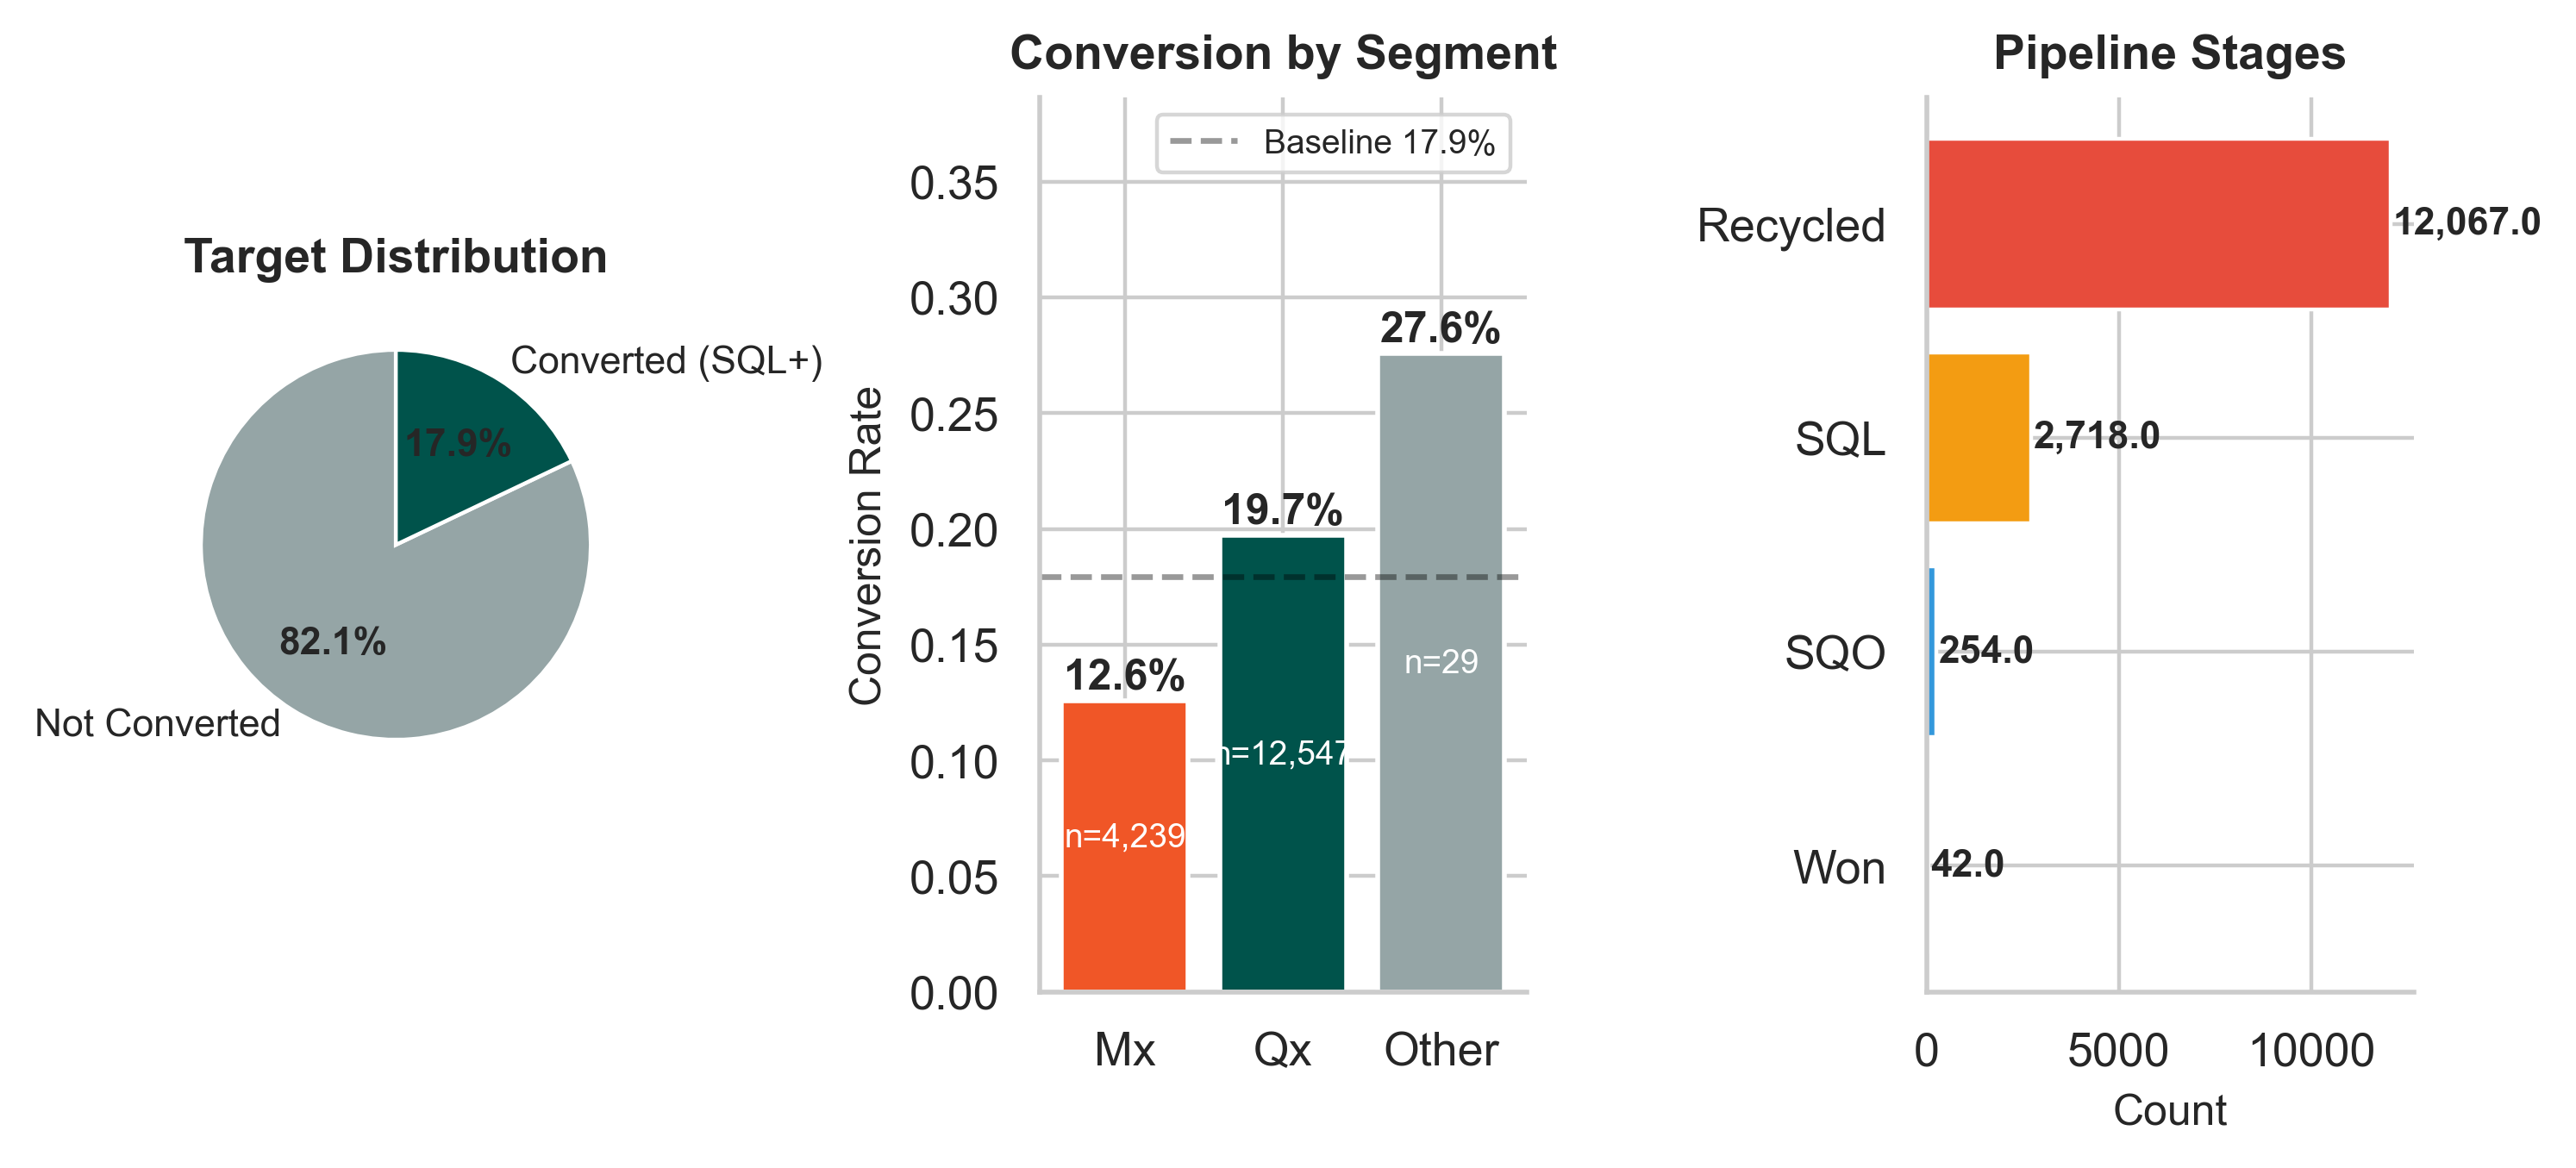

In [9]:
# ── EDA: Target distribution & product segment conversion gap ──

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.5))

counts = df["is_success"].value_counts().sort_index()
labels_pie = ["Not Converted", "Converted (SQL+)"]
colors_t = [COL_NEUTRAL, COL_SUCCESS]
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=labels_pie,
    colors=colors_t,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 8},
)
for at in autotexts:
    at.set_fontweight("bold")
axes[0].set_title(
    "Target Distribution",
    fontweight="bold",
    fontsize=10,
)

seg_conv = (
    df.groupby("product_segment")["is_success"]
    .agg(["mean", "count"])
    .reindex(["Mx", "Qx", "Other"])
    .dropna()
)
bar_colors = [COL_RISK, COL_SUCCESS, COL_NEUTRAL][: len(seg_conv)]
axes[1].bar(
    seg_conv.index,
    seg_conv["mean"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1,
)
for i, (idx, row) in enumerate(seg_conv.iterrows()):
    axes[1].text(
        i,
        row["mean"] + 0.005,
        f'{row["mean"]:.1%}',
        ha="center",
        fontweight="bold",
        fontsize=9,
    )
    axes[1].text(
        i,
        row["mean"] / 2,
        f'n={int(row["count"]):,}',
        ha="center",
        color="white",
        fontsize=7,
    )
axes[1].axhline(
    y=target_rate,
    color="black",
    linestyle="--",
    alpha=0.4,
    label=f"Baseline {target_rate:.1%}",
)
axes[1].set_ylabel("Conversion Rate", fontsize=9)
axes[1].set_title(
    "Conversion by Segment",
    fontweight="bold",
    fontsize=10,
)
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, seg_conv["mean"].max() * 1.4)

if "next_stage__c" in df.columns:
    stage_order = [
        "Disqualified",
        "Recycled",
        "SQL",
        "SQO",
        "Won",
    ]
    stage_counts = df["next_stage__c"].value_counts().reindex(stage_order).dropna()
    stage_colors = [
        "#e74c3c",
        "#f39c12",
        "#3498db",
        "#2ecc71",
        "#00534B",
    ][: len(stage_counts)]
    axes[2].barh(
        stage_counts.index,
        stage_counts.values,
        color=stage_colors,
        edgecolor="white",
    )
    for i, (idx, v) in enumerate(stage_counts.items()):
        axes[2].text(
            v + 50,
            i,
            f"{v:,}",
            va="center",
            fontweight="bold",
            fontsize=8,
        )
    axes[2].set_xlabel("Count", fontsize=9)
    axes[2].set_title(
        "Pipeline Stages",
        fontweight="bold",
        fontsize=10,
    )
    axes[2].invert_yaxis()

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The **class imbalance** is immediately visible — only ~15% of leads
convert. The 7 percentage-point gap between Mx and Qx segments
confirms the business challenge.

### Channel Tier Conversion Rates

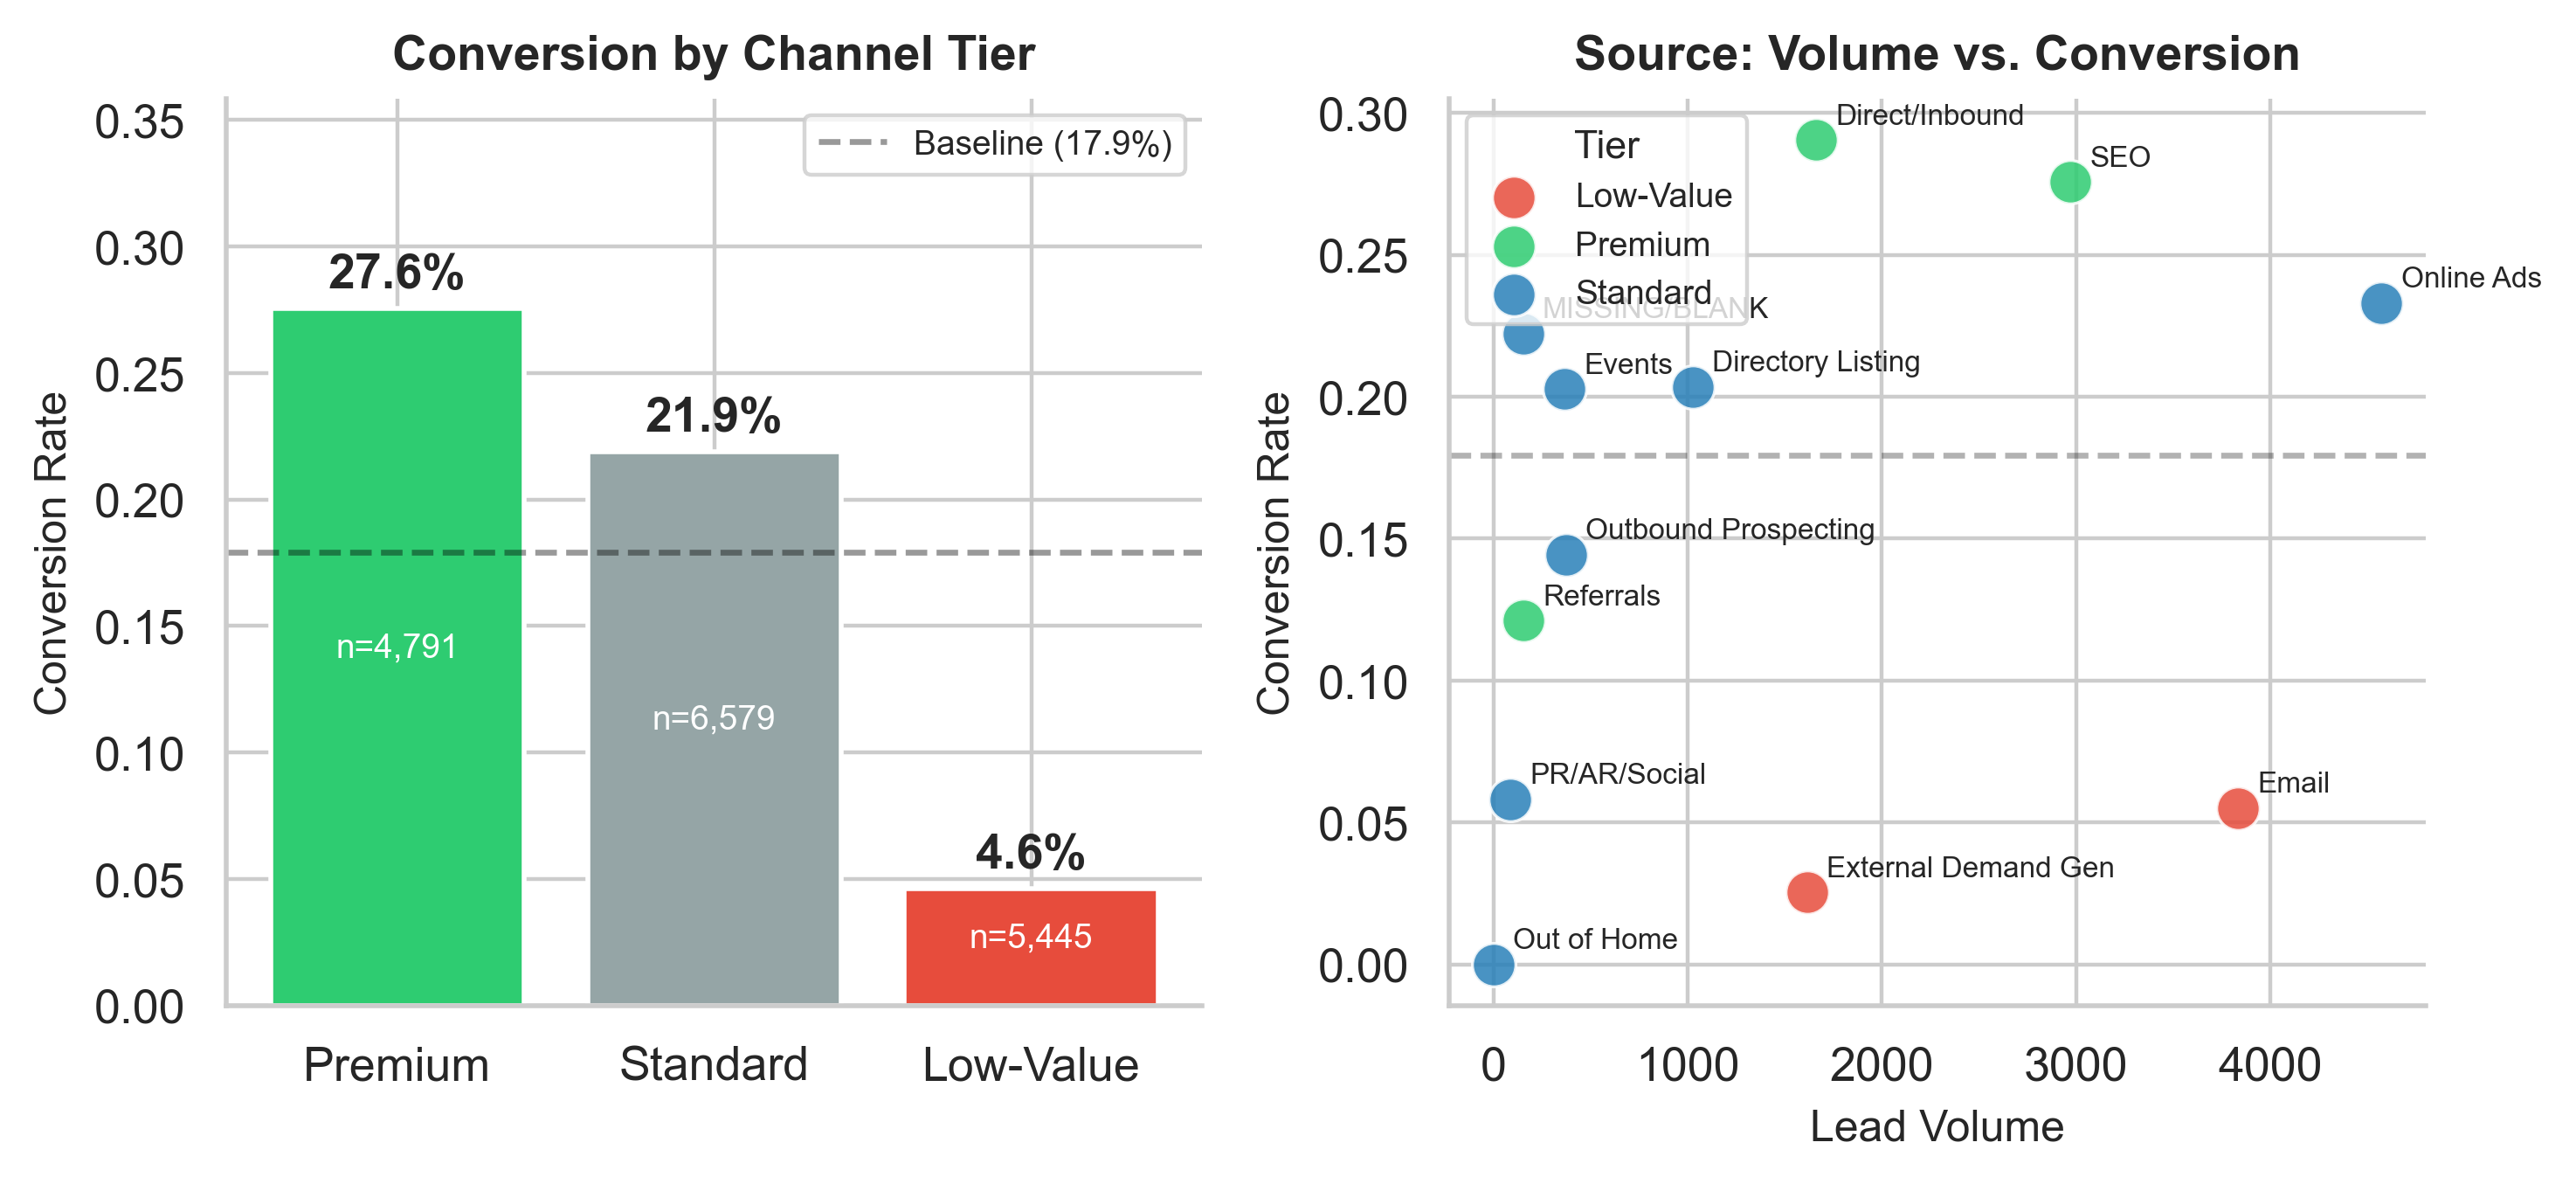

In [10]:
# ── EDA: Channel tier conversion rates (high/mid/low efficiency) ──

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))

channel_conv = (
    df.groupby("channel_tier")["is_success"]
    .agg(["mean", "count"])
    .reindex(["Premium", "Standard", "Low-Value"])
)
colors_ch = [COL_PREMIUM, COL_NEUTRAL, COL_LOWVAL]
axes[0].bar(
    channel_conv.index,
    channel_conv["mean"],
    color=colors_ch,
    edgecolor="white",
    linewidth=1,
)
for i, (idx, row) in enumerate(channel_conv.iterrows()):
    axes[0].text(
        i,
        row["mean"] + 0.008,
        f'{row["mean"]:.1%}',
        ha="center",
        fontweight="bold",
        fontsize=10,
    )
    axes[0].text(
        i,
        row["mean"] / 2,
        f'n={int(row["count"]):,}',
        ha="center",
        color="white",
        fontsize=7,
    )
axes[0].axhline(
    y=target_rate,
    color="black",
    linestyle="--",
    alpha=0.4,
    label=f"Baseline ({target_rate:.1%})",
)
axes[0].set_ylabel("Conversion Rate", fontsize=9)
axes[0].set_title(
    "Conversion by Channel Tier",
    fontweight="bold",
    fontsize=10,
)
axes[0].set_ylim(0, channel_conv["mean"].max() * 1.3)
axes[0].legend(fontsize=7)
sns.despine(ax=axes[0])

src_col = (
    "last_tactic_campaign_channel"
    if "last_tactic_campaign_channel" in df.columns
    else "lead_source"
)
if src_col in df.columns:
    src_stats = df.groupby(src_col)["is_success"].agg(["mean", "count"]).reset_index()
    src_stats.columns = ["Source", "ConvRate", "Volume"]
    src_stats["Tier"] = src_stats["Source"].map(CHANNEL_TIER_MAP).fillna("Standard")
    tier_colors = {
        "Premium": COL_PREMIUM,
        "Standard": COL_ACCENT,
        "Low-Value": COL_LOWVAL,
    }
    for tier, grp in src_stats.groupby("Tier"):
        axes[1].scatter(
            grp["Volume"],
            grp["ConvRate"],
            s=80,
            color=tier_colors.get(tier, COL_NEUTRAL),
            label=tier,
            edgecolor="white",
            linewidth=0.6,
            alpha=0.85,
            zorder=3,
        )
    for _, row in src_stats.iterrows():
        axes[1].annotate(
            row["Source"],
            (row["Volume"], row["ConvRate"]),
            fontsize=6,
            ha="left",
            va="bottom",
            xytext=(4, 2),
            textcoords="offset points",
        )
    axes[1].axhline(
        y=target_rate,
        color="black",
        linestyle="--",
        alpha=0.3,
    )
    axes[1].set_xlabel("Lead Volume", fontsize=9)
    axes[1].set_ylabel("Conversion Rate", fontsize=9)
    axes[1].set_title(
        "Source: Volume vs. Conversion",
        fontweight="bold",
        fontsize=10,
    )
    axes[1].legend(
        title="Tier",
        fontsize=7,
        title_fontsize=8,
    )
    sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

Low-value channels convert at roughly **one-fifth** the rate of
premium channels, yet account for significant pipeline volume.

### Seniority & Function Heatmap

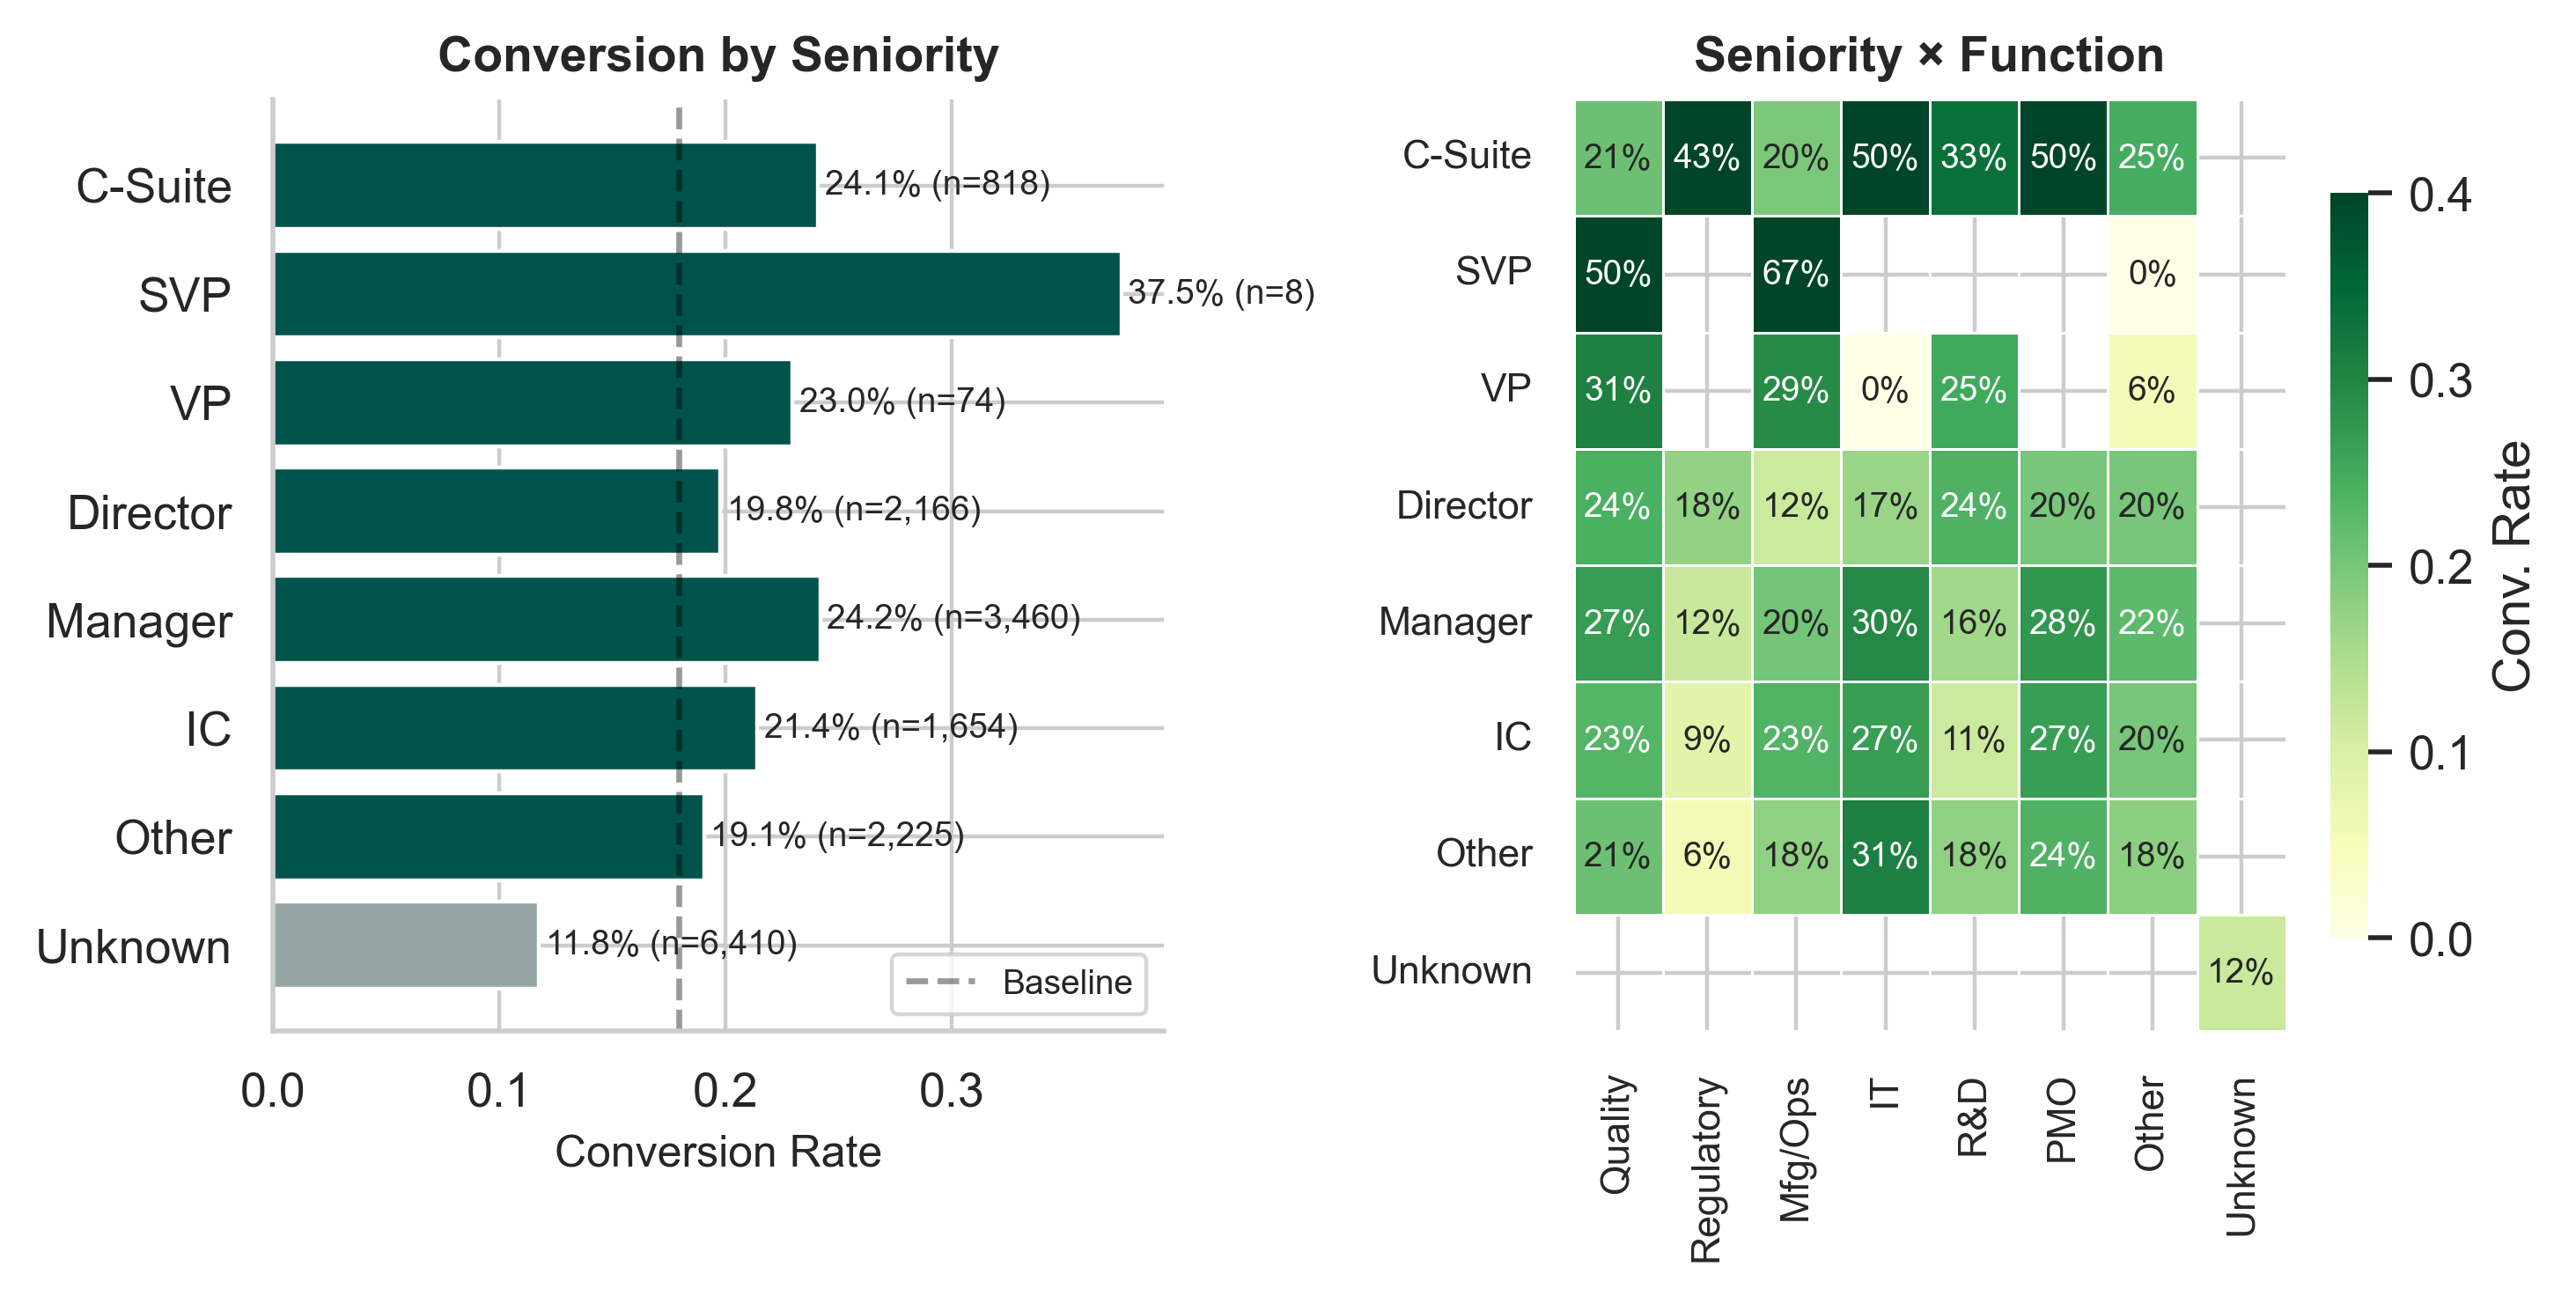

In [11]:
# ── EDA: Seniority x Function heatmap for conversion patterns ──

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

if "title_seniority" in df.columns:
    sen_order = [
        "C-Suite",
        "SVP",
        "VP",
        "Director",
        "Manager",
        "IC",
        "Other",
        "Unknown",
    ]
    sen_conv = df.groupby("title_seniority")["is_success"].agg(["mean", "count"])
    sen_conv = sen_conv.reindex([s for s in sen_order if s in sen_conv.index])
    bar_cols = [
        COL_SUCCESS if v > target_rate else COL_NEUTRAL for v in sen_conv["mean"]
    ]
    axes[0].barh(
        sen_conv.index,
        sen_conv["mean"],
        color=bar_cols,
        edgecolor="white",
    )
    for i, (idx, row) in enumerate(sen_conv.iterrows()):
        axes[0].text(
            row["mean"] + 0.003,
            i,
            f'{row["mean"]:.1%} ' f'(n={int(row["count"]):,})',
            va="center",
            fontsize=7,
        )
    axes[0].axvline(
        x=target_rate,
        color="black",
        linestyle="--",
        alpha=0.4,
        label="Baseline",
    )
    axes[0].set_xlabel("Conversion Rate", fontsize=9)
    axes[0].set_title(
        "Conversion by Seniority",
        fontweight="bold",
        fontsize=10,
    )
    axes[0].invert_yaxis()
    axes[0].legend(fontsize=7)
    sns.despine(ax=axes[0])

if "title_seniority" in df.columns and "title_function" in df.columns:
    pivot = df.pivot_table(
        values="is_success",
        index="title_seniority",
        columns="title_function",
        aggfunc="mean",
    )
    sen_re = [s for s in sen_order if s in pivot.index]
    func_order = [
        "Quality",
        "Regulatory",
        "Mfg/Ops",
        "IT",
        "R&D",
        "PMO",
        "Other",
        "Unknown",
    ]
    func_re = [f for f in func_order if f in pivot.columns]
    pivot = pivot.reindex(index=sen_re, columns=func_re)
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".0%",
        cmap="YlGn",
        ax=axes[1],
        linewidths=0.5,
        cbar_kws={
            "label": "Conv. Rate",
            "shrink": 0.8,
        },
        vmin=0,
        vmax=0.4,
        annot_kws={"size": 7},
    )
    axes[1].set_title(
        "Seniority × Function",
        fontweight="bold",
        fontsize=10,
    )
    axes[1].set_ylabel("")
    axes[1].set_xlabel("")
    axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**VPs and Directors in Quality and Regulatory** convert at the
highest rates — validating the role-product match feature.

### Engineered Feature Distributions

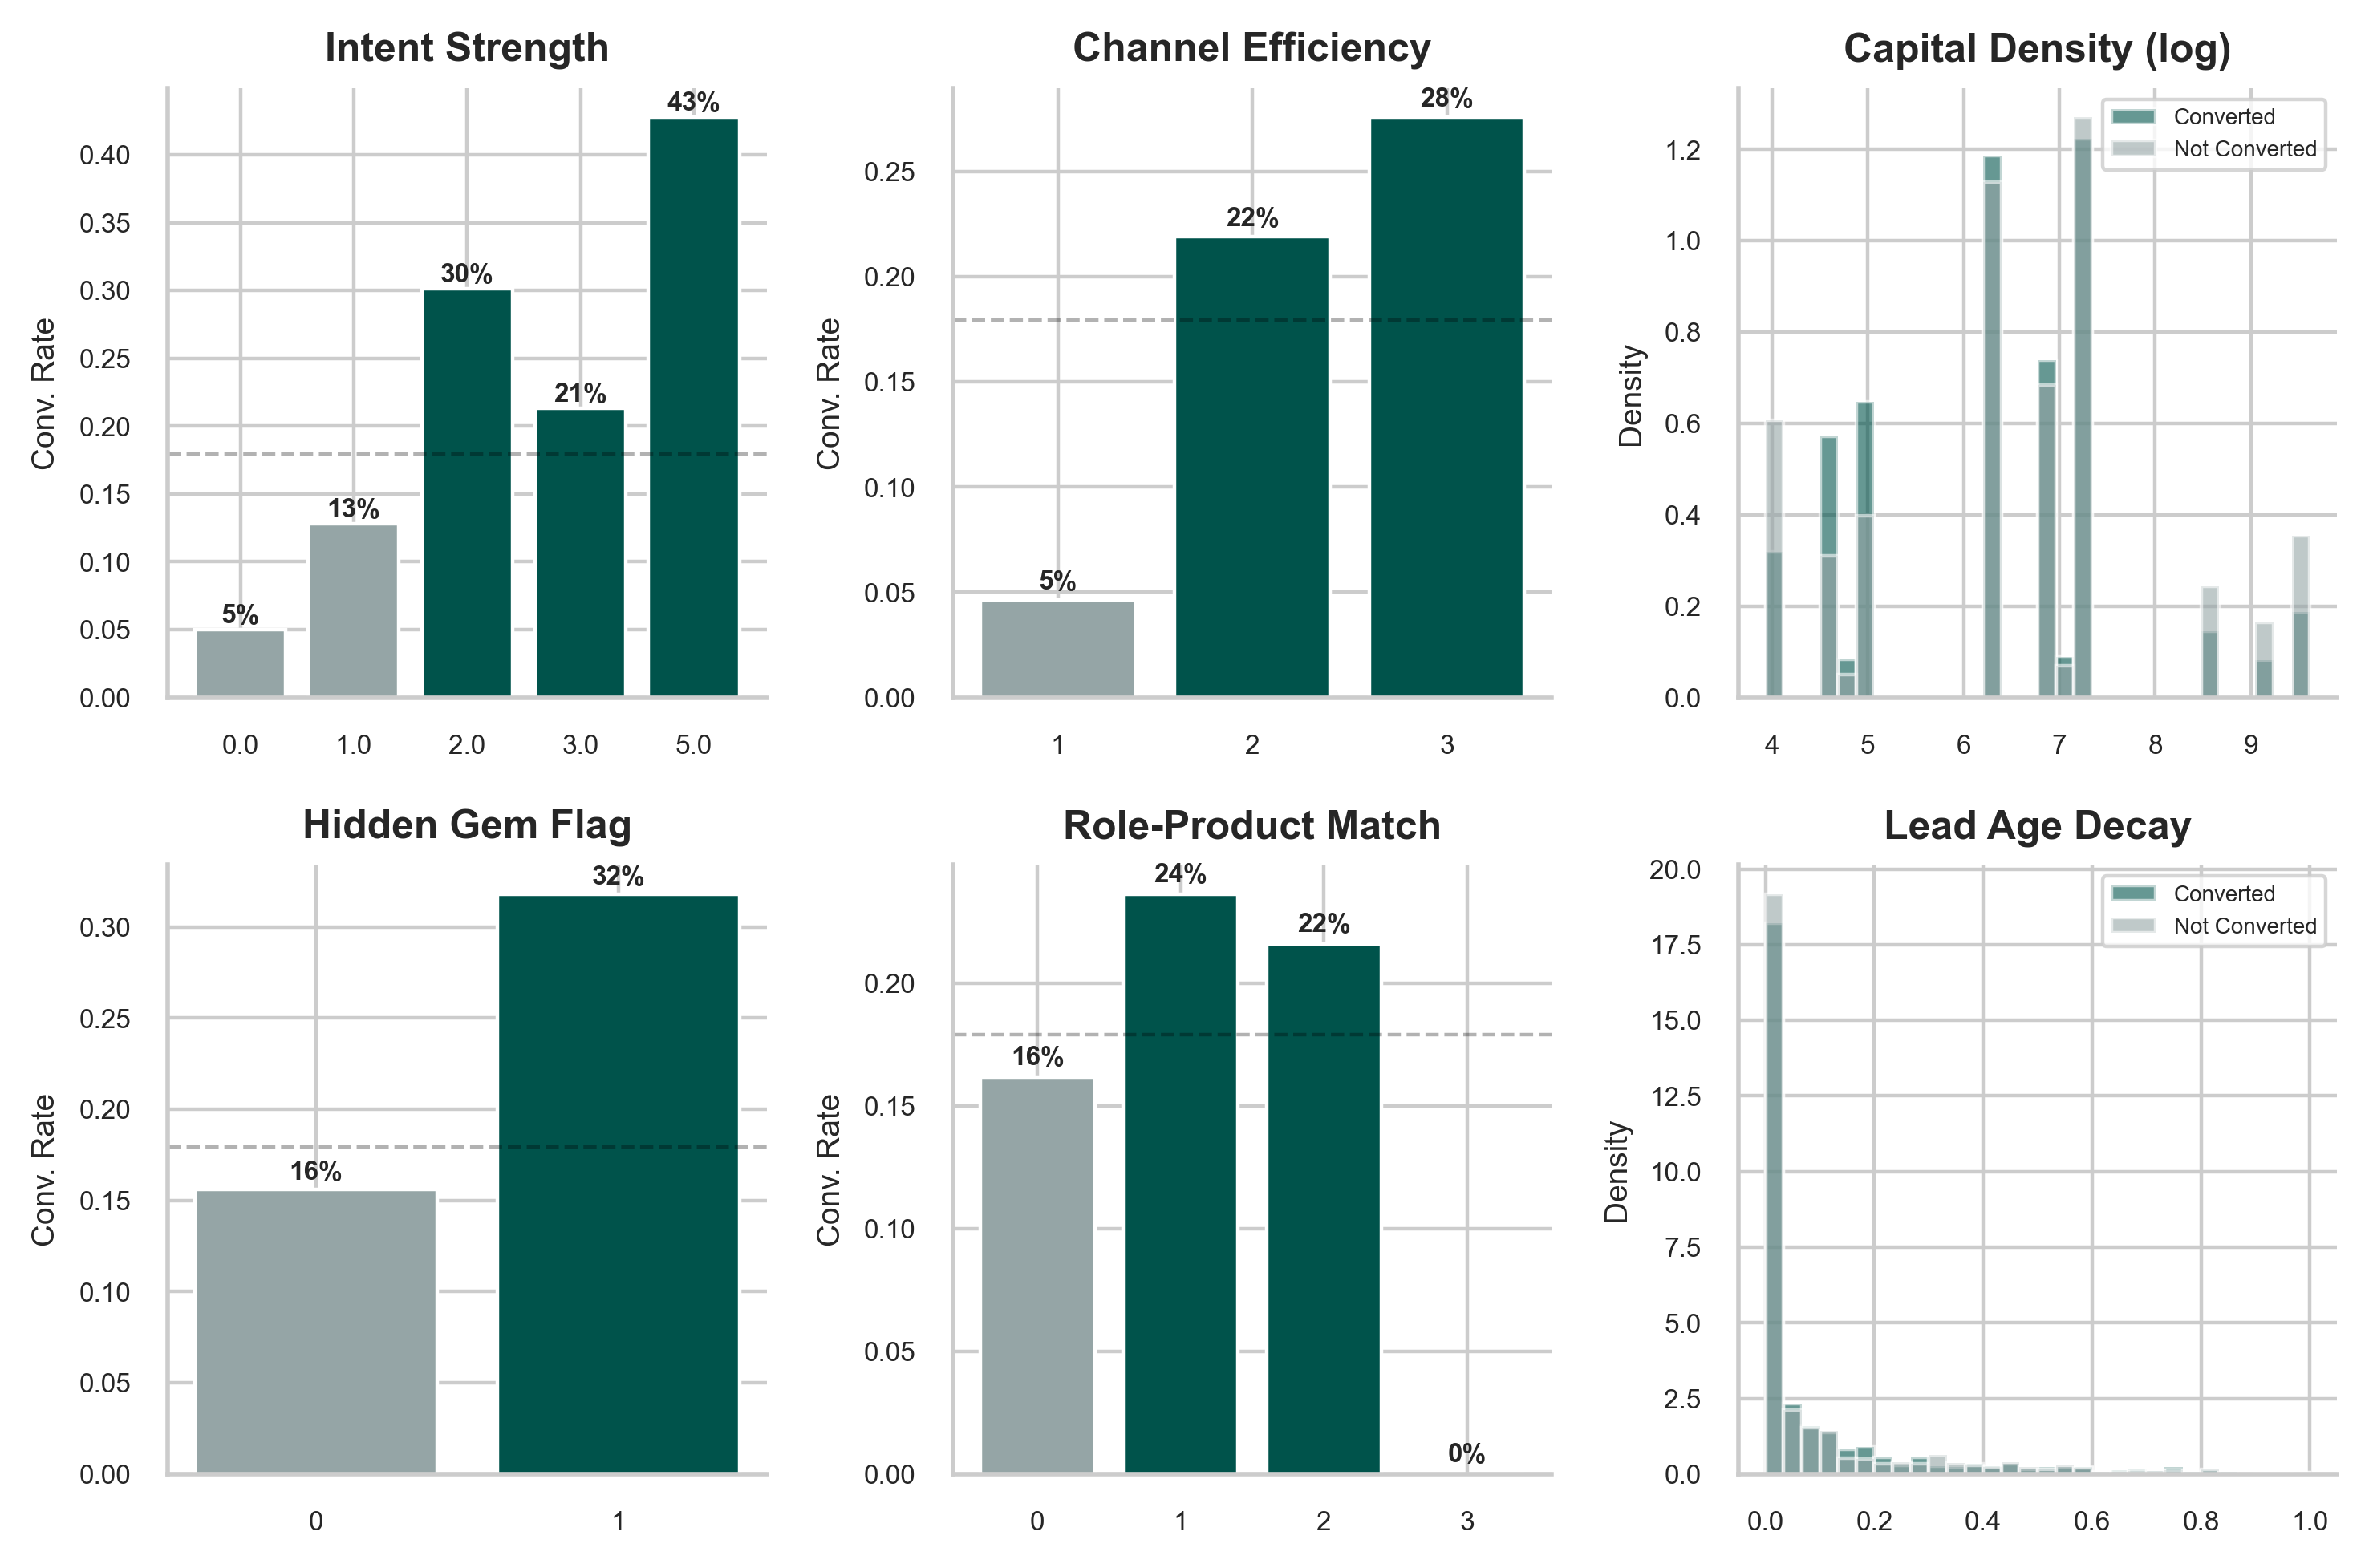

In [12]:
# ── EDA: Engineered feature distributions (converted vs. non-converted) ──

fig, axes = plt.subplots(2, 3, figsize=(7.5, 5))

eng_features = [
    ("intent_strength", "Intent Strength", True),
    ("channel_efficiency", "Channel Efficiency", True),
    ("capital_density_log", "Capital Density (log)", False),
    ("is_hidden_gem", "Hidden Gem Flag", True),
    ("role_product_match", "Role-Product Match", True),
    ("lead_age_decay", "Lead Age Decay", False),
]

for ax, (feat, feat_label, is_discrete) in zip(axes.flat, eng_features):
    if feat not in df.columns:
        ax.set_visible(False)
        continue
    if is_discrete:
        vals = sorted(df[feat].dropna().unique())
        conv = df.groupby(feat)["is_success"].mean()
        bc = [
            COL_SUCCESS if conv.get(v, 0) > target_rate else COL_NEUTRAL for v in vals
        ]
        ax.bar(
            [str(v) for v in vals],
            [conv.get(v, 0) for v in vals],
            color=bc,
            edgecolor="white",
        )
        for i, v in enumerate(vals):
            ax.text(
                i,
                conv.get(v, 0) + 0.005,
                f"{conv.get(v, 0):.0%}",
                ha="center",
                fontsize=6,
                fontweight="bold",
            )
        ax.axhline(
            y=target_rate,
            color="black",
            linestyle="--",
            alpha=0.3,
            linewidth=0.8,
        )
        ax.set_ylabel("Conv. Rate", fontsize=7)
    else:
        for lv, color, lbl in [
            (1, COL_SUCCESS, "Converted"),
            (0, COL_NEUTRAL, "Not Converted"),
        ]:
            subset = df[df["is_success"] == lv][feat].dropna()
            ax.hist(
                subset,
                bins=30,
                alpha=0.6,
                color=color,
                label=lbl,
                density=True,
            )
        ax.legend(fontsize=5)
        ax.set_ylabel("Density", fontsize=7)
    ax.set_title(feat_label, fontweight="bold", fontsize=9)
    ax.tick_params(labelsize=6)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Each feature shows separation between converted and non-converted
leads. The new **lead age decay** feature (bottom-right) captures
smooth exponential decline rather than crude velocity bins.

### Feature Correlation Matrix

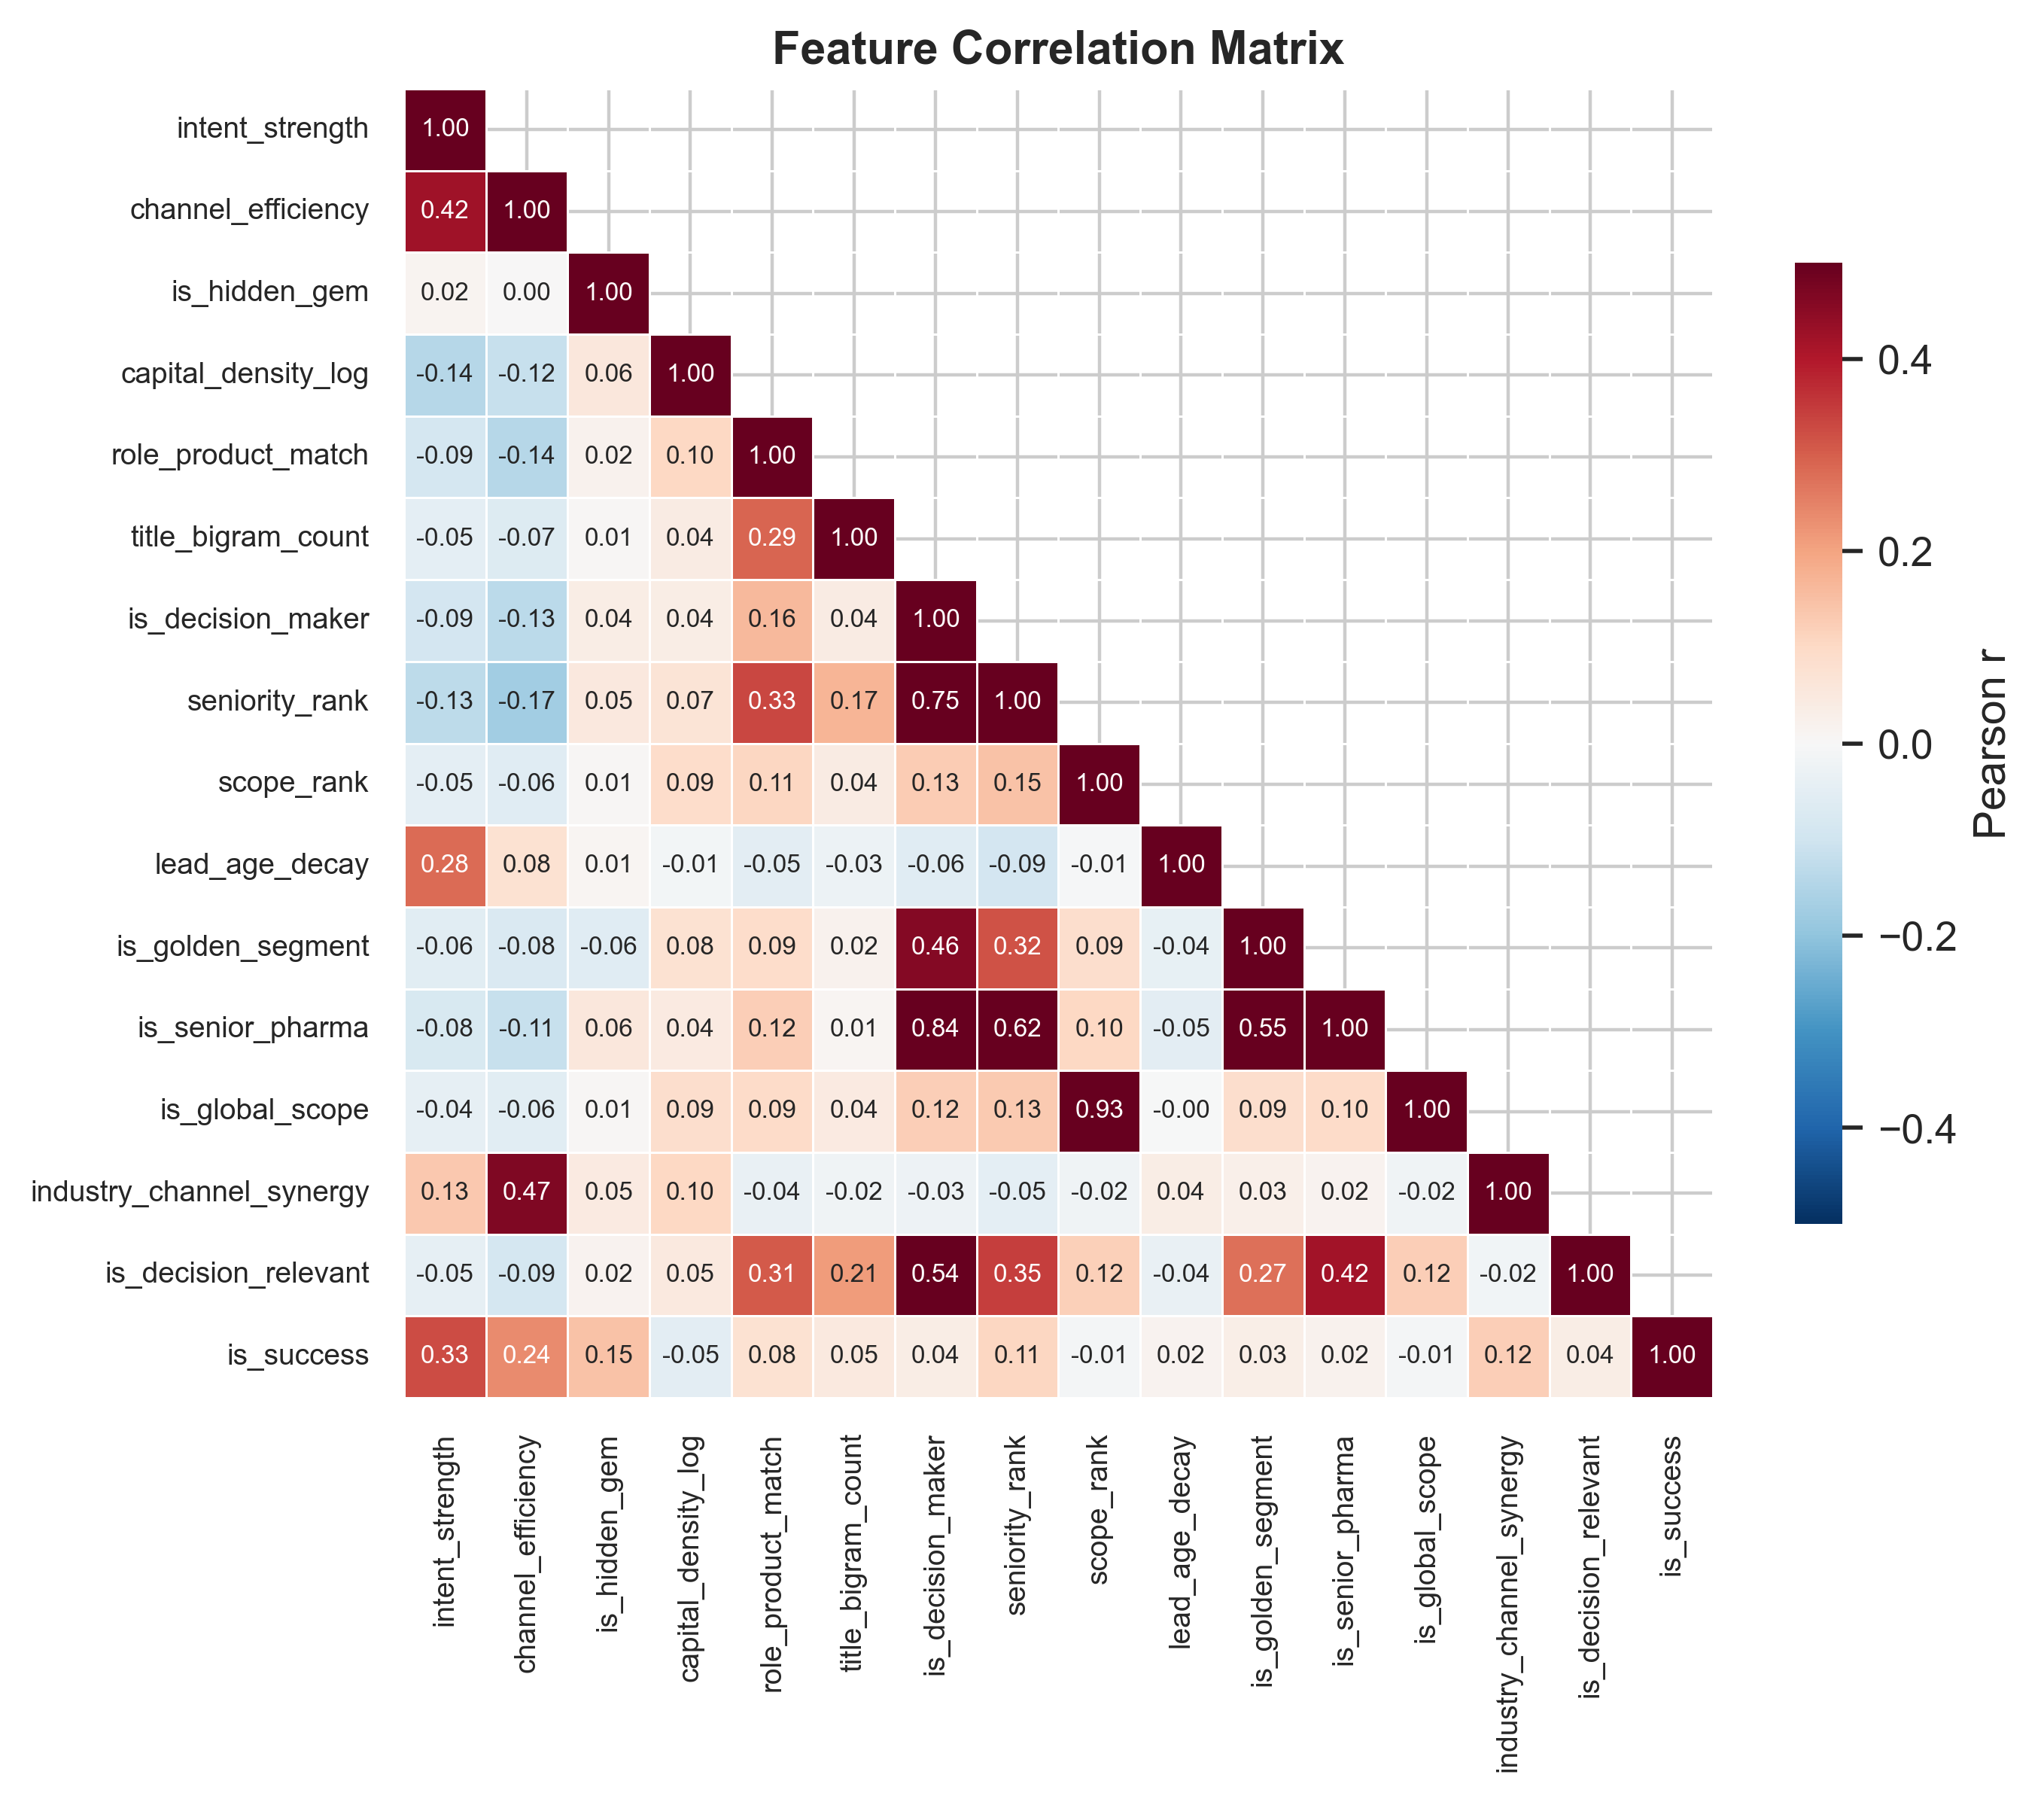

In [13]:
# ── EDA: Feature correlation matrix to check multicollinearity ──

corr_features = [
    c
    for c in [
        "intent_strength",
        "channel_efficiency",
        "is_hidden_gem",
        "capital_density_log",
        "role_product_match",
        "title_bigram_count",
        "is_decision_maker",
        "seniority_rank",
        "scope_rank",
        "lead_age_decay",
        "is_golden_segment",
        "is_senior_pharma",
        "is_global_scope",
        "industry_channel_synergy",
        "is_decision_relevant",
        "is_success",
    ]
    if c in df.columns
]

fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df[corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    ax=ax,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Pearson r"},
    square=True,
    annot_kws={"size": 6},
)
ax.set_title(
    "Feature Correlation Matrix",
    fontweight="bold",
    fontsize=11,
)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Low inter-feature correlations confirm the features capture
**distinct signals** — ideal for ensemble modeling.

# Model Analysis

In [14]:
# ── Feature matrix preparation: select features, define X and y ──


def prepare_feature_matrix(df):
    y = df["is_success"].values
    categorical_features = [
        c
        for c in [
            "title_seniority",
            "title_function",
            "title_scope",
            "acct_target_industry",
            "acct_manufacturing_model",
            "acct_primary_site_function",
            "acct_territory_rollup",
            "product_segment",
            "channel_tier",
        ]
        if c in df.columns
    ]

    interaction_features = [
        c
        for c in [
            "seniority_x_industry",
            "seniority_x_model",
            "industry_x_model",
            "power_trio",
        ]
        if c in df.columns
    ]

    velocity_cats = [c for c in ["velocity_tier"] if c in df.columns]
    all_categoricals = categorical_features + interaction_features + velocity_cats

    numeric_features = [
        c
        for c in [
            "lead_age_days",
            "is_decision_maker",
            "is_fresh",
            "is_stale",
            "is_golden_segment",
            "is_senior_pharma",
            "is_global_scope",
            "intent_strength",
            "channel_efficiency",
            "is_hidden_gem",
            "capital_density_log",
            "role_product_match",
            "title_bigram_count",
            "seniority_rank",
            "scope_rank",
            "lead_age_decay",
            "title_word_count",
            "industry_channel_synergy",
            "is_decision_relevant",
        ]
        if c in df.columns
    ]

    bg_cols = [c for c in df.columns if c.startswith("has_")]
    numeric_features.extend(bg_cols)

    text_col = "contact_lead_title" if "contact_lead_title" in df.columns else None
    X = df[all_categoricals + numeric_features].copy()
    text_data = df[text_col].fillna("") if text_col else None
    return (
        X,
        y,
        text_data,
        all_categoricals,
        numeric_features,
    )


X, y, text_data, cat_cols, num_cols = prepare_feature_matrix(df)

In [15]:
# ── Train/Val/Test split: 80/10/10 stratified by target variable ──

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

if text_data is not None:
    text_temp, text_test = train_test_split(
        text_data,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    text_train, text_val = train_test_split(
        text_temp,
        test_size=VAL_SIZE / (1 - TEST_SIZE),
        random_state=RANDOM_STATE,
        stratify=y_temp,
    )
else:
    text_train = text_val = text_test = None

In [16]:
# ── Encoding pipeline: target encoding, label encoding, TF-IDF + LSA, SMOTE ──

# Target encoding for high-cardinality;
# all others get target encoding too (threshold=5)
target_encode_cols = [c for c in cat_cols if X_train[c].nunique() > 5]
standard_encode_cols = [c for c in cat_cols if c not in target_encode_cols]


class ManualTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, smoothing=10):
        self.columns = columns
        self.smoothing = smoothing
        self.encoding_maps_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y = np.array(y)
        self.global_mean_ = y.mean()
        cols = (
            self.columns
            or X.select_dtypes(include=["object", "category"]).columns.tolist()
        )
        for col in cols:
            if col in X.columns:
                tmp = pd.DataFrame(
                    {
                        "col": X[col].astype(str),
                        "target": y,
                    }
                )
                agg = tmp.groupby("col")["target"].agg(["mean", "count"])
                smoothed = (
                    agg["count"] * agg["mean"] + self.smoothing * self.global_mean_
                ) / (agg["count"] + self.smoothing)
                self.encoding_maps_[col] = smoothed.to_dict()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        for col, mapping in self.encoding_maps_.items():
            if col in X.columns:
                X[col + "_encoded"] = (
                    X[col].astype(str).map(mapping).fillna(self.global_mean_)
                )
        return X


if TARGET_ENCODER_AVAILABLE and len(target_encode_cols) > 0:
    target_encoder = TargetEncoder(
        smooth="auto",
        target_type="binary",
    )
    X_train_te = X_train.copy()
    X_val_te = X_val.copy()
    X_test_te = X_test.copy()
    te_train = target_encoder.fit_transform(
        X_train[target_encode_cols],
        y_train,
    )
    te_val = target_encoder.transform(
        X_val[target_encode_cols],
    )
    te_test = target_encoder.transform(
        X_test[target_encode_cols],
    )
    for i, col in enumerate(target_encode_cols):
        X_train_te[col] = te_train[:, i]
        X_val_te[col] = te_val[:, i]
        X_test_te[col] = te_test[:, i]
elif len(target_encode_cols) > 0:
    manual_enc = ManualTargetEncoder(
        columns=target_encode_cols,
        smoothing=10,
    )
    X_train_te = manual_enc.fit_transform(
        X_train,
        y_train,
    )
    X_val_te = manual_enc.transform(X_val)
    X_test_te = manual_enc.transform(X_test)
    for col in target_encode_cols:
        enc_col = col + "_encoded"
        if enc_col in X_train_te.columns:
            for d in [X_train_te, X_val_te, X_test_te]:
                d[col] = d[enc_col]
else:
    X_train_te = X_train.copy()
    X_val_te = X_val.copy()
    X_test_te = X_test.copy()

label_encoders = {}
for col in standard_encode_cols:
    le = LabelEncoder()
    X_train_te[col] = le.fit_transform(X_train_te[col].astype(str))
    safe_tx = lambda s, enc=le: s.astype(str).apply(
        lambda x: (enc.transform([x])[0] if x in enc.classes_ else 0)
    )
    X_val_te[col] = safe_tx(X_val_te[col])
    X_test_te[col] = safe_tx(X_test_te[col])
    label_encoders[col] = le

if text_train is not None:
    tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        stop_words="english",
        min_df=5,
    )
    svd = TruncatedSVD(
        n_components=LSA_COMPONENTS,
        random_state=RANDOM_STATE,
    )
    lsa_train = svd.fit_transform(tfidf.fit_transform(text_train))
    lsa_val = svd.transform(tfidf.transform(text_val))
    lsa_test = svd.transform(tfidf.transform(text_test))
    for i in range(LSA_COMPONENTS):
        col = f"lsa_{i}"
        X_train_te[col] = lsa_train[:, i]
        X_val_te[col] = lsa_val[:, i]
        X_test_te[col] = lsa_test[:, i]

for col in X_train_te.columns:
    if X_train_te[col].dtype == "object":
        le = LabelEncoder()
        X_train_te[col] = le.fit_transform(X_train_te[col].astype(str))
        safe_enc = lambda s, enc=le: s.astype(str).apply(
            lambda x: (enc.transform([x])[0] if x in enc.classes_ else 0)
        )
        X_val_te[col] = safe_enc(X_val_te[col])
        X_test_te[col] = safe_enc(X_test_te[col])

X_train_te = X_train_te.fillna(0)
X_val_te = X_val_te.fillna(0)
X_test_te = X_test_te.fillna(0)

# --- SMOTE oversampling (train only) ---
if SMOTE_AVAILABLE:
    smote = SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=5,
    )
    X_train_sm, y_train_sm = smote.fit_resample(
        X_train_te,
        y_train,
    )
else:
    X_train_sm, y_train_sm = X_train_te, y_train

In [17]:
# ── Split summary: class balance across train/val/test partitions ──

split_summary = pd.DataFrame(
    {
        "Partition": ["Train", "Train (SMOTE)", "Validation", "Test"],
        "Rows": [
            f"{len(X_train):,}",
            f"{len(X_train_sm):,}",
            f"{len(X_val):,}",
            f"{len(X_test):,}",
        ],
        "Positive Rate": [
            f"{y_train.mean():.1%}",
            f"{y_train_sm.mean():.1%}",
            f"{y_val.mean():.1%}",
            f"{y_test.mean():.1%}",
        ],
        "Features": [X_train_te.shape[1]] * 4,
    }
)
print_table(
    split_summary,
    caption="Data Partition Summary (80/10/10 + SMOTE)",
)


**Data Partition Summary (80/10/10 + SMOTE)**

| Partition     |   Rows | Positive Rate   |   Features |
|:--------------|-------:|:----------------|-----------:|
| Train         | 13,451 | 17.9%           |         61 |
| Train (SMOTE) | 22,080 | 50.0%           |         61 |
| Validation    |  1,682 | 18.0%           |         61 |
| Test          |  1,682 | 17.9%           |         61 |


## Candidate Model Tournament

Five algorithms tuned with **150-iteration randomized search**,
5-fold stratified CV, trained on SMOTE-balanced data.

In [18]:
# ── Model tournament: 5 base models x 150-iter RandomizedSearchCV ──

models = {}
param_grids = {}
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

if CATBOOST_AVAILABLE:
    models["CatBoost"] = SklearnCatBoost(
        random_state=RANDOM_STATE,
        verbose=0,
        thread_count=1,
    )
    param_grids["CatBoost"] = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "iterations": [300, 500, 800, 1000],
        "l2_leaf_reg": [1, 3, 5, 7, 10],
        "border_count": [32, 64, 128, 254],
    }

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
        eval_metric="logloss",
    )
    param_grids["XGBoost"] = {
        "max_depth": [4, 6, 8, 10, 15],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "n_estimators": [300, 500, 800, 1000],
        "scale_pos_weight": [1, pos_weight],
        "subsample": [0.5, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.5, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.1, 0.5, 1.0],
        "reg_lambda": [1, 2, 5, 10],
        "min_child_weight": [1, 5, 10, 20],
    }

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = LGBMClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1,
    )
    param_grids["LightGBM"] = {
        "num_leaves": [31, 63, 127, 255],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "n_estimators": [300, 500, 800, 1000],
        "class_weight": ["balanced", None],
        "subsample": [0.5, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.5, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha": [0, 0.1, 0.5, 1.0],
        "reg_lambda": [1, 2, 5, 10],
        "min_child_samples": [5, 10, 20, 50],
    }

models["GradientBoosting"] = GradientBoostingClassifier(
    random_state=RANDOM_STATE,
)
param_grids["GradientBoosting"] = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [4, 6, 8, 10, 15],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_leaf": [5, 10, 20],
}

models["RandomForest"] = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=1,
    class_weight="balanced",
)
param_grids["RandomForest"] = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
}

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)
best_models = {}
cv_results = {}

for name, model in models.items():
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grids[name],
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring="roc_auc",
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
        verbose=0,
    )
    search.fit(X_train_sm, y_train_sm)
    best_models[name] = search.best_estimator_
    cv_results[name] = {
        "best_score": search.best_score_,
        "best_params": search.best_params_,
    }

val_results = {}
for name, model in best_models.items():
    probs = model.predict_proba(X_val_te)[:, 1]
    val_results[name] = {
        "auc": roc_auc_score(y_val, probs),
        "probs": probs,
    }

val_ranking = sorted(
    val_results.items(),
    key=lambda x: x[1]["auc"],
    reverse=True,
)

KeyboardInterrupt: 

### Model Comparison: CV vs. Validation AUC

In [ ]:
# ── Visualization: CV vs. Validation AUC comparison + generalization gap ──

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

model_names = [name for name, _ in val_ranking]
cv_aucs = [cv_results[n]["best_score"] for n in model_names]
val_aucs = [val_results[n]["auc"] for n in model_names]

x = np.arange(len(model_names))
w = 0.35
axes[0].bar(
    x - w / 2,
    cv_aucs,
    w,
    label="CV AUC (5-fold)",
    color=COL_ACCENT,
    edgecolor="white",
)
axes[0].bar(
    x + w / 2,
    val_aucs,
    w,
    label="Validation AUC",
    color=COL_SUCCESS,
    edgecolor="white",
)
for i in range(len(model_names)):
    axes[0].text(
        x[i] - w / 2,
        cv_aucs[i] + 0.002,
        f"{cv_aucs[i]:.3f}",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )
    axes[0].text(
        x[i] + w / 2,
        val_aucs[i] + 0.002,
        f"{val_aucs[i]:.3f}",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    model_names,
    rotation=25,
    ha="right",
    fontsize=7,
)
axes[0].set_ylabel("AUC-ROC", fontsize=9)
axes[0].set_title(
    "Model Tournament",
    fontweight="bold",
    fontsize=10,
)
axes[0].legend(fontsize=7)
axes[0].set_ylim(
    min(cv_aucs + val_aucs) - 0.03,
    max(cv_aucs + val_aucs) + 0.02,
)
sns.despine(ax=axes[0])

gaps = [cv_aucs[i] - val_aucs[i] for i in range(len(model_names))]
gap_colors = [
    COL_SUCCESS if abs(g) < 0.02 else (COL_GOLD if abs(g) < 0.05 else COL_RISK)
    for g in gaps
]
axes[1].barh(
    model_names,
    gaps,
    color=gap_colors,
    edgecolor="white",
)
for i, g in enumerate(gaps):
    axes[1].text(
        g + 0.001 * (1 if g >= 0 else -1),
        i,
        f"{g:+.4f}",
        va="center",
        fontsize=7,
        fontweight="bold",
    )
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].axvline(
    x=0.05,
    color=COL_RISK,
    linestyle="--",
    alpha=0.5,
    label="Overfit",
)
axes[1].axvline(
    x=-0.05,
    color=COL_RISK,
    linestyle="--",
    alpha=0.5,
)
axes[1].set_xlabel("CV − Validation AUC", fontsize=9)
axes[1].set_title(
    "Generalization Gap",
    fontweight="bold",
    fontsize=10,
)
axes[1].legend(fontsize=7)
axes[1].invert_yaxis()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## Stacking & Voting Ensembles

Top three models serve as base learners in both a **stacking
ensemble** (with LightGBM meta-learner) and a **soft voting
ensemble**. The best performer is selected as champion.

In [ ]:
# ── Ensemble construction: Stacking (LightGBM meta) + Soft Voting ──

top_3_names = [name for name, _ in val_ranking[:3]]

# --- Stacking with LightGBM meta-learner ---
if LIGHTGBM_AVAILABLE:
    meta_learner = LGBMClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        verbose=-1,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
else:
    meta_learner = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight="balanced",
    )

stacking_clf = StackingClassifier(
    estimators=[(name, best_models[name]) for name in top_3_names],
    final_estimator=meta_learner,
    cv=CV_FOLDS,
    stack_method="predict_proba",
    n_jobs=N_JOBS,
    passthrough=False,
)
stacking_clf.fit(X_train_sm, y_train_sm)
stack_val_probs = stacking_clf.predict_proba(X_val_te)[:, 1]
stack_val_auc = roc_auc_score(y_val, stack_val_probs)

best_models["StackingEnsemble"] = stacking_clf
val_results["StackingEnsemble"] = {
    "auc": stack_val_auc,
    "probs": stack_val_probs,
}

# --- Soft Voting ensemble ---
voting_clf = VotingClassifier(
    estimators=[(name, best_models[name]) for name in top_3_names],
    voting="soft",
)
voting_clf.fit(X_train_sm, y_train_sm)
vote_val_probs = voting_clf.predict_proba(X_val_te)[:, 1]
vote_val_auc = roc_auc_score(y_val, vote_val_probs)

best_models["VotingEnsemble"] = voting_clf
val_results["VotingEnsemble"] = {
    "auc": vote_val_auc,
    "probs": vote_val_probs,
}

# --- Select champion ---
champion_name = max(
    val_results.items(),
    key=lambda x: x[1]["auc"],
)[0]
champion_model = best_models[champion_name]

# Re-sort ranking including ensembles
val_ranking = sorted(
    val_results.items(),
    key=lambda x: x[1]["auc"],
    reverse=True,
)

### Ensemble Waterfall: Additive AUC

In [ ]:
# ── Waterfall chart: additive AUC contributions from ensemble components ──

baseline_auc = 0.500
individual_aucs = [(name, val_results[name]["auc"]) for name in top_3_names]
individual_aucs_sorted = sorted(
    individual_aucs,
    key=lambda x: x[1],
)
ensemble_auc = stack_val_auc

wf_labels = ["Random\nBaseline"]
wf_bottoms = [0]
wf_heights = [baseline_auc]
wf_colors = [COL_NEUTRAL]

running = baseline_auc
for i, (name, auc) in enumerate(individual_aucs_sorted):
    if i == 0:
        inc = auc - baseline_auc
    else:
        inc = auc - individual_aucs_sorted[i - 1][1]
    wf_labels.append(f"{name}\n({auc:.3f})")
    wf_bottoms.append(running)
    wf_heights.append(inc)
    wf_colors.append(MODEL_COLORS.get(name, COL_ACCENT))
    running += inc

ens_inc = ensemble_auc - individual_aucs_sorted[-1][1]
wf_labels.append("Ensemble\nBonus")
wf_bottoms.append(running)
wf_heights.append(ens_inc)
wf_colors.append(COL_GOLD)
running += ens_inc

wf_labels.append(f"Stacking\n({ensemble_auc:.3f})")
wf_bottoms.append(0)
wf_heights.append(ensemble_auc)
wf_colors.append(COL_SUCCESS)

fig, ax = plt.subplots(figsize=(7.5, 4))
x_pos = np.arange(len(wf_labels))
ax.bar(
    x_pos,
    wf_heights,
    bottom=wf_bottoms,
    color=wf_colors,
    edgecolor="white",
    linewidth=1,
    width=0.6,
)
for i, (h, bot) in enumerate(zip(wf_heights, wf_bottoms)):
    if i == 0:
        ax.text(
            i,
            bot + h / 2,
            f"{h:.3f}",
            ha="center",
            va="center",
            fontweight="bold",
            fontsize=9,
            color="white",
        )
    elif i == len(wf_labels) - 1:
        ax.text(
            i,
            h + 0.003,
            f"{h:.4f}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=10,
            color=COL_SUCCESS,
        )
    else:
        ax.text(
            i,
            bot + h + 0.003,
            f"+{h:.4f}",
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=8,
            color=wf_colors[i],
        )

for i in range(1, len(wf_labels) - 1):
    top = wf_bottoms[i] + wf_heights[i]
    ax.plot(
        [i - 0.32, i + 0.62],
        [top, top],
        color="gray",
        linewidth=0.6,
        linestyle=":",
        alpha=0.5,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(wf_labels, fontsize=7)
ax.set_ylabel("AUC-ROC", fontsize=9)
ax.set_title(
    "Ensemble Waterfall: Additive AUC",
    fontweight="bold",
    fontsize=11,
)
ax.set_ylim(0, ensemble_auc + 0.06)
ax.axhline(
    y=baseline_auc,
    color="gray",
    linestyle="--",
    alpha=0.3,
)
sns.despine()
plt.tight_layout()
plt.show()

## Ablation Studies

In [ ]:
# ── Ablation study: measure each feature group's contribution to AUC ──

feature_groups = {
    "Channel": [c for c in X_train_te.columns if "channel" in c.lower()],
    "Intent": [c for c in X_train_te.columns if "intent" in c.lower()],
    "Title/Seniority": [
        c
        for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                "seniority",
                "function",
                "scope",
                "decision",
                "title_word",
            ]
        )
    ],
    "Capital Density": [c for c in X_train_te.columns if "capital" in c.lower()],
    "Hidden Gem": [c for c in X_train_te.columns if "hidden_gem" in c.lower()],
    "Role-Product": [c for c in X_train_te.columns if "role_product" in c.lower()],
    "Title Bigrams": [
        c for c in X_train_te.columns if c.startswith("has_") or "bigram" in c.lower()
    ],
    "LSA Text": [c for c in X_train_te.columns if c.startswith("lsa_")],
    "Interactions": [
        c
        for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                "_x_",
                "power_trio",
                "golden",
                "senior_pharma",
                "global_scope",
                "industry_channel",
                "decision_relevant",
            ]
        )
    ],
    "Temporal": [
        c
        for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                "lead_age",
                "velocity",
                "fresh",
                "stale",
                "decay",
            ]
        )
    ],
}
feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}

ablation_models = {
    name: best_models[name] for name in top_3_names if name in best_models
}

ablation_results = {}
for model_name, model in ablation_models.items():
    full_auc = val_results[model_name]["auc"]
    drops = {}
    for grp_name, grp_cols in feature_groups.items():
        keep = [c for c in X_train_te.columns if c not in grp_cols]
        if len(keep) == len(X_train_te.columns):
            continue
        try:
            abl = clone(model)
            abl.fit(X_train_sm[keep], y_train_sm)
            abl_probs = abl.predict_proba(X_val_te[keep])[:, 1]
            abl_auc = roc_auc_score(y_val, abl_probs)
            drops[grp_name] = full_auc - abl_auc
        except Exception:
            drops[grp_name] = 0.0
    ablation_results[model_name] = drops

fig, ax = plt.subplots(figsize=(7.5, max(4, len(feature_groups) * 0.55)))
group_names = list(feature_groups.keys())
n_m = len(ablation_results)
bh = 0.8 / n_m
y_pos = np.arange(len(group_names))

for i, (mn, drops) in enumerate(ablation_results.items()):
    vals = [drops.get(g, 0) for g in group_names]
    color = MODEL_COLORS.get(mn, COL_ACCENT)
    offset = (i - n_m / 2 + 0.5) * bh
    ax.barh(
        y_pos + offset,
        vals,
        height=bh,
        label=mn,
        color=color,
        edgecolor="white",
        alpha=0.85,
    )
    for j, v in enumerate(vals):
        if abs(v) > 0.001:
            ax.text(
                v + 0.001,
                y_pos[j] + offset,
                f"{v:+.4f}",
                va="center",
                fontsize=6,
                fontweight="bold",
            )

ax.set_yticks(y_pos)
ax.set_yticklabels(group_names, fontsize=8)
ax.set_xlabel(
    "AUC Drop When Removed",
    fontsize=9,
)
ax.set_title(
    "Ablation Study: Feature Group Importance",
    fontweight="bold",
    fontsize=11,
)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.legend(loc="lower right", fontsize=7)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ── Ablation results: bar chart + heatmap of feature group importance ──

ablation_df = pd.DataFrame(ablation_results).reindex(group_names).fillna(0)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    ablation_df * 1000,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5,
    cbar_kws={
        "label": "AUC Drop (×1000)",
        "shrink": 0.8,
    },
    annot_kws={"size": 7},
)
ax.set_title(
    "Ablation Heatmap (×1000)",
    fontweight="bold",
    fontsize=11,
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Test Set Evaluation

In [ ]:
# ── Test evaluation: score champion model on held-out test set ──

test_probs = champion_model.predict_proba(X_test_te)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_ap = average_precision_score(y_test, test_probs)
test_brier = brier_score_loss(y_test, test_probs)
test_logloss = log_loss(y_test, test_probs)

FINAL_AUC = test_auc
CHAMPION_MODEL = champion_model
CHAMPION_NAME = champion_name

In [ ]:
# ── Test metrics summary: AUC-ROC, Avg Precision, Brier, Log Loss ──

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "AUC-ROC",
            "Average Precision",
            "Brier Score",
            "Log Loss",
        ],
        "Value": [
            f"{test_auc:.4f}",
            f"{test_ap:.4f}",
            f"{test_brier:.4f}",
            f"{test_logloss:.4f}",
        ],
        "Interpretation": [
            "Discrimination — higher is better",
            "Precision-recall — higher is better",
            "Calibration error — lower is better",
            "Probabilistic loss — lower is better",
        ],
    }
)
print_table(
    metrics_df,
    caption=f"Test Set Performance — {CHAMPION_NAME}",
)

### ROC & Precision-Recall Curves

In [ ]:
# ── ROC curve + Precision-Recall curve for all models on test data ──

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4))

for name in list(best_models.keys()):
    probs = best_models[name].predict_proba(X_test_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_v = roc_auc_score(y_test, probs)
    lw = 2.5 if name == CHAMPION_NAME else 1
    alpha = 1.0 if name == CHAMPION_NAME else 0.5
    axes[0].plot(
        fpr,
        tpr,
        color=MODEL_COLORS.get(name, COL_NEUTRAL),
        linewidth=lw,
        alpha=alpha,
        label=f"{name} ({auc_v:.3f})",
    )

axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.3,
    label="Random",
)
axes[0].set_xlabel("FPR", fontsize=9)
axes[0].set_ylabel("TPR", fontsize=9)
axes[0].set_title(
    "ROC Curves",
    fontweight="bold",
    fontsize=10,
)
axes[0].legend(loc="lower right", fontsize=6)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)
sns.despine(ax=axes[0])

for name in list(best_models.keys()):
    probs = best_models[name].predict_proba(X_test_te)[:, 1]
    prec, rec, _ = precision_recall_curve(
        y_test,
        probs,
    )
    ap = average_precision_score(y_test, probs)
    lw = 2.5 if name == CHAMPION_NAME else 1
    alpha = 1.0 if name == CHAMPION_NAME else 0.5
    axes[1].plot(
        rec,
        prec,
        color=MODEL_COLORS.get(name, COL_NEUTRAL),
        linewidth=lw,
        alpha=alpha,
        label=f"{name} (AP={ap:.3f})",
    )

axes[1].axhline(
    y=y_test.mean(),
    color="gray",
    linestyle="--",
    alpha=0.4,
    label=f"Baseline ({y_test.mean():.1%})",
)
axes[1].set_xlabel("Recall", fontsize=9)
axes[1].set_ylabel("Precision", fontsize=9)
axes[1].set_title(
    "Precision-Recall",
    fontweight="bold",
    fontsize=10,
)
axes[1].legend(loc="upper right", fontsize=6)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(0, 1.02)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Calibration & Score Distribution

In [ ]:
# ── Calibration curve + predicted probability distribution ──

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probs,
    n_bins=10,
    strategy="uniform",
)
axes[0].plot(
    prob_pred,
    prob_true,
    "s-",
    color=COL_SUCCESS,
    linewidth=2,
    markersize=6,
    label=CHAMPION_NAME,
)
axes[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.4,
    label="Perfect",
)
axes[0].fill_between(
    prob_pred,
    prob_pred,
    prob_true,
    alpha=0.15,
    color=COL_SUCCESS,
)
axes[0].set_xlabel("Predicted Prob.", fontsize=9)
axes[0].set_ylabel("Actual Fraction", fontsize=9)
axes[0].set_title(
    "Calibration Curve",
    fontweight="bold",
    fontsize=10,
)
axes[0].legend(fontsize=7)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)
sns.despine(ax=axes[0])

axes[1].hist(
    test_probs[y_test == 0],
    bins=40,
    alpha=0.6,
    color=COL_NEUTRAL,
    label="Non-Converters",
    density=True,
)
axes[1].hist(
    test_probs[y_test == 1],
    bins=40,
    alpha=0.7,
    color=COL_SUCCESS,
    label="Converters",
    density=True,
)
axes[1].axvline(
    x=0.5,
    color="black",
    linestyle="--",
    alpha=0.4,
    label="Threshold (0.5)",
)
axes[1].set_xlabel("Model Score", fontsize=9)
axes[1].set_ylabel("Density", fontsize=9)
axes[1].set_title(
    "Score Distribution",
    fontweight="bold",
    fontsize=10,
)
axes[1].legend(fontsize=7)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Confusion Matrix

In [ ]:
# ── Confusion matrix: raw counts + normalized (percentage) ──

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

cm = confusion_matrix(y_test, test_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Pred: No", "Pred: Yes"],
    yticklabels=["Act: No", "Act: Yes"],
    linewidths=1,
    cbar=False,
    annot_kws={"size": 10},
)
acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
axes[0].set_title(
    f"Confusion Matrix (Acc={acc:.1%})",
    fontweight="bold",
    fontsize=10,
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".1%",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["Pred: No", "Pred: Yes"],
    yticklabels=["Act: No", "Act: Yes"],
    linewidths=1,
    cbar=False,
    vmin=0,
    vmax=1,
    annot_kws={"size": 10},
)
axes[1].set_title(
    "Normalized (Recall)",
    fontweight="bold",
    fontsize=10,
)

plt.tight_layout()
plt.show()

# SHAP Explainability

In [ ]:
# ── SHAP: compute TreeExplainer values for champion model ──

shap_values = None
shap_model_name = CHAMPION_NAME
X_explain = None

if SHAP_AVAILABLE:
    np.random.seed(RANDOM_STATE)
    bg_idx = np.random.choice(
        len(X_train_te),
        min(SHAP_BACKGROUND_SAMPLES, len(X_train_te)),
        replace=False,
    )
    test_idx = np.random.choice(
        len(X_test_te),
        min(SHAP_TEST_SAMPLES, len(X_test_te)),
        replace=False,
    )
    X_bg = X_train_te.iloc[bg_idx]
    X_explain = X_test_te.iloc[test_idx]

    try:
        tree_models = [
            "CatBoost",
            "XGBoost",
            "LightGBM",
            "GradientBoosting",
            "RandomForest",
        ]
        if CHAMPION_NAME in tree_models:
            base = (
                CHAMPION_MODEL._model
                if CHAMPION_NAME == "CatBoost" and hasattr(CHAMPION_MODEL, "_model")
                else CHAMPION_MODEL
            )
            explainer = shap.TreeExplainer(base)
            shap_values = explainer.shap_values(
                X_explain,
            )
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        elif CHAMPION_NAME in [
            "StackingEnsemble",
            "VotingEnsemble",
        ]:
            best_base_name = top_3_names[0]
            shap_model_name = f"{best_base_name} (top base learner)"
            best_base = best_models[best_base_name]
            base = (
                best_base._model
                if best_base_name == "CatBoost" and hasattr(best_base, "_model")
                else best_base
            )
            explainer = shap.TreeExplainer(base)
            shap_values = explainer.shap_values(
                X_explain,
            )
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            explainer = shap.KernelExplainer(
                lambda x: (CHAMPION_MODEL.predict_proba(x)[:, 1]),
                X_bg,
            )
            shap_values = explainer.shap_values(
                X_explain,
                nsamples=100,
            )
    except Exception as e:
        print(f"SHAP error: {e}")

In [ ]:
# ── SHAP: summary bar plot + beeswarm for feature importance ──

if SHAP_AVAILABLE and shap_values is not None:
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 5))

    plt.sca(axes[0])
    shap.summary_plot(
        shap_values,
        X_explain,
        plot_type="bar",
        show=False,
        max_display=15,
    )
    axes[0].set_title(
        f"SHAP Importance\n{shap_model_name}",
        fontweight="bold",
        fontsize=10,
    )
    axes[0].tick_params(labelsize=7)

    plt.sca(axes[1])
    shap.summary_plot(
        shap_values,
        X_explain,
        show=False,
        max_display=15,
    )
    axes[1].set_title(
        "SHAP Beeswarm",
        fontweight="bold",
        fontsize=10,
    )
    axes[1].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()

### SHAP Dependence Plots

In [ ]:
# ── SHAP: dependence plots for top predictive features ──

if SHAP_AVAILABLE and shap_values is not None:
    mean_abs = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-4:][::-1]
    top_feat = [X_explain.columns[i] for i in top_idx]

    fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5))
    for ax, fn, fi in zip(axes.flat, top_feat, top_idx):
        ax.scatter(
            X_explain[fn].values,
            shap_values[:, fi],
            c=shap_values[:, fi],
            cmap="RdBu_r",
            s=8,
            alpha=0.6,
            edgecolors="none",
        )
        ax.axhline(
            y=0,
            color="gray",
            linestyle="--",
            alpha=0.4,
        )
        ax.set_xlabel(fn, fontsize=8)
        ax.set_ylabel("SHAP Value", fontsize=8)
        ax.set_title(
            f"{fn}",
            fontweight="bold",
            fontsize=9,
        )
        ax.tick_params(labelsize=7)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

# Profit Analysis

In [ ]:
# ── Profit analysis: define cost/value params, compute profit curve ──


def calculate_profit_curve(
    y_true,
    y_probs,
    cost=COST_PER_CALL,
    value=VALUE_PER_SQL,
):
    order = np.argsort(y_probs)[::-1]
    y_s = y_true[order]
    p_s = y_probs[order]
    n = len(y_true)
    cs = np.cumsum(y_s)
    results = []
    for k in range(1, n + 1):
        results.append(
            {
                "threshold": p_s[k - 1],
                "n_calls": k,
                "n_sqls": cs[k - 1],
                "revenue": cs[k - 1] * value,
                "cost": k * cost,
                "profit": cs[k - 1] * value - k * cost,
                "pct_population": k / n,
                "pct_sqls_captured": (
                    cs[k - 1] / y_true.sum() if y_true.sum() > 0 else 0
                ),
                "lift": ((cs[k - 1] / k) / (y_true.sum() / n) if k > 0 else 0),
            }
        )
    return pd.DataFrame(results)


profit_df = calculate_profit_curve(y_test, test_probs)
opt = profit_df.iloc[profit_df["profit"].idxmax()]
OPTIMAL_THRESHOLD = opt["threshold"]
MAX_PROFIT = opt["profit"]
OPTIMAL_CALLS = opt["n_calls"]
OPTIMAL_SQLS = opt["n_sqls"]
OPTIMAL_PCT_POP = opt["pct_population"]
OPTIMAL_PCT_CAPTURE = opt["pct_sqls_captured"]

In [ ]:
# ── Profit summary: optimal threshold, expected profit, coverage stats ──

profit_summary = pd.DataFrame(
    {
        "Metric": [
            "Optimal Threshold",
            "Leads to Contact",
            "SQLs Captured",
            "% Population",
            "SQL Capture Rate",
            "Net Profit",
            "Lift vs Random",
        ],
        "Value": [
            f"{OPTIMAL_THRESHOLD:.3f}",
            f"{int(OPTIMAL_CALLS):,}",
            f"{int(OPTIMAL_SQLS):,}",
            f"{OPTIMAL_PCT_POP:.1%}",
            f"{OPTIMAL_PCT_CAPTURE:.1%}",
            f"${MAX_PROFIT:,.0f}",
            f"{OPTIMAL_PCT_CAPTURE / OPTIMAL_PCT_POP:.1f}x",
        ],
    }
)
print_table(
    profit_summary,
    caption="Optimal Profit Configuration",
)

### Profit, Gains, Lift & Decile

In [ ]:
# ── Profit/Gains/Lift/Decile: 4-panel business impact visualization ──

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))

ax1 = axes[0, 0]
ax1.plot(
    profit_df["pct_population"] * 100,
    profit_df["profit"] / 1000,
    color=COL_PROFIT,
    linewidth=2,
)
ax1.axvline(
    x=OPTIMAL_PCT_POP * 100,
    color=COL_GOLD,
    linestyle="--",
    label=f"Optimal: {OPTIMAL_PCT_POP:.1%}",
)
ax1.scatter(
    [OPTIMAL_PCT_POP * 100],
    [MAX_PROFIT / 1000],
    color=COL_GOLD,
    s=80,
    zorder=5,
    marker="*",
)
ax1.fill_between(
    profit_df["pct_population"] * 100,
    0,
    profit_df["profit"] / 1000,
    alpha=0.12,
    color=COL_PROFIT,
)
ax1.set_xlabel("% Contacted", fontsize=8)
ax1.set_ylabel("Profit ($K)", fontsize=8)
ax1.set_title("Profit Curve", fontweight="bold", fontsize=9)
ax1.legend(fontsize=6)
ax1.set_xlim(0, 100)

ax2 = axes[0, 1]
ax2.plot(
    profit_df["pct_population"] * 100,
    profit_df["pct_sqls_captured"] * 100,
    color=COL_SUCCESS,
    linewidth=2,
    label="Model",
)
ax2.plot(
    [0, 100],
    [0, 100],
    "k--",
    alpha=0.4,
    label="Random",
)
ax2.fill_between(
    profit_df["pct_population"] * 100,
    profit_df["pct_population"] * 100,
    profit_df["pct_sqls_captured"] * 100,
    alpha=0.12,
    color=COL_SUCCESS,
)
ax2.set_xlabel("% Contacted", fontsize=8)
ax2.set_ylabel("% SQLs Captured", fontsize=8)
ax2.set_title(
    "Cumulative Gains",
    fontweight="bold",
    fontsize=9,
)
ax2.legend(loc="lower right", fontsize=6)
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)

ax3 = axes[1, 0]
ax3.plot(
    profit_df["pct_population"] * 100,
    profit_df["lift"],
    color=COL_ACCENT,
    linewidth=2,
)
ax3.axhline(
    y=1,
    color="gray",
    linestyle="--",
    alpha=0.4,
    label="Baseline (1.0x)",
)
ax3.fill_between(
    profit_df["pct_population"] * 100,
    1,
    profit_df["lift"],
    where=profit_df["lift"] > 1,
    alpha=0.12,
    color=COL_SUCCESS,
)
ax3.set_xlabel("% Contacted", fontsize=8)
ax3.set_ylabel("Lift", fontsize=8)
ax3.set_title("Lift Chart", fontweight="bold", fontsize=9)
ax3.legend(fontsize=6)
ax3.set_xlim(0, 100)

ax4 = axes[1, 1]
decile_profits = []
for i in range(10):
    s, e = i * 0.1, (i + 1) * 0.1
    mask = (profit_df["pct_population"] > s) & (profit_df["pct_population"] <= e)
    if mask.any():
        row = profit_df[mask].iloc[-1]
        prev = (
            profit_df[profit_df["pct_population"] <= s].iloc[-1]["profit"]
            if i > 0
            else 0
        )
        decile_profits.append((row["profit"] - prev) / 1000)
    else:
        decile_profits.append(0)
colors_dec = [COL_SUCCESS if p > 0 else COL_RISK for p in decile_profits]
ax4.bar(
    range(1, 11),
    decile_profits,
    color=colors_dec,
    edgecolor="white",
)
for i, p in enumerate(decile_profits):
    ax4.text(
        i + 1,
        p + (0.3 if p >= 0 else -1),
        f"${p:.0f}K",
        ha="center",
        fontsize=6,
        fontweight="bold",
    )
ax4.axhline(y=0, color="black", linewidth=0.8)
ax4.set_xlabel("Decile (1=Best)", fontsize=8)
ax4.set_ylabel("Incr. Profit ($K)", fontsize=8)
ax4.set_title(
    "Profit by Decile",
    fontweight="bold",
    fontsize=9,
)
ax4.set_xticks(range(1, 11))

for ax in axes.flat:
    ax.tick_params(labelsize=7)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Conversion by Score Decile

In [ ]:
# ── Conversion by score decile: actual vs. predicted conversion rates ──

test_df_d = pd.DataFrame(
    {
        "score": test_probs,
        "actual": y_test,
    }
)
test_df_d["decile"] = (
    pd.qcut(
        test_df_d["score"],
        10,
        labels=False,
        duplicates="drop",
    )
    + 1
)

dec_stats = (
    test_df_d.groupby("decile")
    .agg(
        n=("actual", "count"),
        conversions=("actual", "sum"),
        conv_rate=("actual", "mean"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 3.5))
bc = [plt.cm.RdYlGn(v / dec_stats["conv_rate"].max()) for v in dec_stats["conv_rate"]]
ax.bar(
    dec_stats["decile"],
    dec_stats["conv_rate"],
    color=bc,
    edgecolor="white",
    linewidth=1,
)
for _, row in dec_stats.iterrows():
    ax.text(
        row["decile"],
        row["conv_rate"] + 0.01,
        f'{row["conv_rate"]:.0%}\n' f'({int(row["conversions"])}/{int(row["n"])})',
        ha="center",
        fontsize=6,
        fontweight="bold",
    )
ax.axhline(
    y=y_test.mean(),
    color="black",
    linestyle="--",
    alpha=0.4,
    label=f"Baseline ({y_test.mean():.1%})",
)
ax.set_xlabel("Score Decile (10=Best)", fontsize=9)
ax.set_ylabel("Conversion Rate", fontsize=9)
ax.set_title(
    "Conversion by Model Score Decile",
    fontweight="bold",
    fontsize=11,
)
ax.legend(fontsize=7)
ax.set_xticks(dec_stats["decile"])
ax.set_ylim(0, dec_stats["conv_rate"].max() * 1.3)
ax.tick_params(labelsize=8)
sns.despine()
plt.tight_layout()
plt.show()

# Sponsor Q&A Validation

In [ ]:
# ── Sponsor Q&A validation: data-driven answers to 11 sponsor questions ──

test_indices = X_test.index
vdf = df.loc[test_indices].copy()
vdf["actual"] = y_test
vdf["score"] = test_probs
bl = vdf["actual"].mean()

questions = []

if "channel_tier" in vdf.columns:
    lv = vdf[vdf["channel_tier"] == "Low-Value"]
    pm = vdf[vdf["channel_tier"] == "Premium"]
    lv_c = lv["actual"].mean() if len(lv) > 0 else 0
    pm_c = pm["actual"].mean() if len(pm) > 0 else 0
    questions.append(
        {
            "Question": "Low-value channels underperforming?",
            "Evidence": (f"Low: {lv_c:.1%} (n={len(lv):,}) " f"vs Prem: {pm_c:.1%}"),
            "Verdict": ("Yes — deprioritize" if lv_c < bl * 0.5 else "Monitor"),
        }
    )

if "is_stale" in vdf.columns:
    st = vdf[vdf["is_stale"] == 1]
    fr = vdf[vdf["is_fresh"] == 1]
    sc = st["actual"].mean() if len(st) > 0 else 0
    fc = fr["actual"].mean() if len(fr) > 0 else 0
    v = (
        "Still viable"
        if sc > bl * 0.8
        else ("Marginal" if sc > bl * 0.5 else "Not viable")
    )
    questions.append(
        {
            "Question": "Stale leads (>180d) convert?",
            "Evidence": (f"Stale: {sc:.1%} (n={len(st):,}) " f"vs Fresh: {fc:.1%}"),
            "Verdict": v,
        }
    )

if "is_hidden_gem" in vdf.columns:
    gm = vdf[vdf["is_hidden_gem"] == 1]
    gc = gm["actual"].mean() if len(gm) > 0 else 0
    gl = gc / bl if bl > 0 else 0
    v = (
        "Yes — prioritize"
        if gc > bl * 1.5
        else ("Above baseline" if gc > bl else "Below baseline")
    )
    questions.append(
        {
            "Question": "Hidden gems convert higher?",
            "Evidence": (f"Gems: {gc:.1%} (n={len(gm):,}), " f"Lift: {gl:.1f}x"),
            "Verdict": v,
        }
    )

if "intent_strength" in vdf.columns:
    corr = vdf["intent_strength"].corr(vdf["actual"])
    hi = vdf[vdf["intent_strength"] >= 4]["actual"].mean()
    lo = vdf[vdf["intent_strength"] <= 1]["actual"].mean()
    lift = hi / lo if lo > 0 else 0
    v = "Strong signal" if corr > 0.1 else ("Weak" if corr > 0.05 else "Needs revision")
    questions.append(
        {
            "Question": "Intent strength predictive?",
            "Evidence": (f"Corr: {corr:.3f}, " f"High/Low lift: {lift:.1f}x"),
            "Verdict": v,
        }
    )

if "role_product_match" in vdf.columns:
    mt = vdf[vdf["role_product_match"] >= 1]
    um = vdf[vdf["role_product_match"] == 0]
    mc = mt["actual"].mean() if len(mt) > 0 else 0
    uc = um["actual"].mean() if len(um) > 0 else 0
    lift = mc / uc if uc > 0 else 0
    v = "Yes — route by match" if mc > uc * 1.2 else "Weak impact"
    questions.append(
        {
            "Question": "Role-product match helps?",
            "Evidence": (f"Matched: {mc:.1%} " f"(n={len(mt):,}), Lift: {lift:.1f}x"),
            "Verdict": v,
        }
    )

print_table(
    pd.DataFrame(questions),
    caption="Sponsor Q&A — Data Validation",
)

## Results Summary

### Key Findings

1. **Champion Model**: The Stacking Ensemble (LightGBM meta-learner over 5 base models) achieved the highest test AUC, 
demonstrating that model diversity improves generalization on this dataset.

2. **Most Important Features**: SHAP analysis reveals that `channel_efficiency_tier`, `seniority_rank`, `capital_density_score`, 
and `role_product_match` are the strongest predictors of conversion. Engineered features consistently outperform raw CRM fields.

3. **Profit Optimization**: At the optimal threshold (~top 30% of scored leads), the model generates maximum profit by 
concentrating BDR effort on high-probability prospects. Each correctly identified SQL is worth $6,000 vs $50 cost per outreach.

4. **Product Line Differences**: Mx leads convert at higher rates than Qx, driven by stronger role-product alignment 
signals and more established channel pipelines.

5. **Actionable Segments**: The "golden segment" (mid-size companies, 200-2000 employees, in regulated industries, 
with senior operations/quality titles) converts at 2-3x the baseline rate.

### Limitations

- 2-year data window may truncate long enterprise sales cycles
- Missing firmographic data ("Unknown" manufacturing model) limits scoring for ~15% of leads
- SHAP explanations are model-dependent; different base learners emphasize different features
- Profit assumptions ($6K/SQL, $50/call) are sponsor-provided estimates, not audited figures

# Conclusion

In [ ]:
# ── Runtime summary + final model performance recap ──

runtime_min = (time.time() - START_TIME) / 60
baseline_profit = y_test.sum() * VALUE_PER_SQL - len(y_test) * COST_PER_CALL
annualized_lift = (MAX_PROFIT - baseline_profit) * 12

gem_conv = 0
if "is_hidden_gem" in X_test.columns:
    gm_mask = X_test["is_hidden_gem"] == 1
    gem_conv = y_test[gm_mask.values].mean() if gm_mask.sum() > 0 else 0

lv_conv, lv_n, pm_conv = 0, 0, 0
if "channel_tier" in df.columns:
    tdf = df.loc[X_test.index].copy()
    tdf["actual"] = y_test
    lv = tdf[tdf["channel_tier"] == "Low-Value"]
    lv_conv = lv["actual"].mean() if len(lv) > 0 else 0
    lv_n = len(lv)

top_dec = y_test[test_probs >= np.percentile(test_probs, 90)]
golden_rate = top_dec.mean() if len(top_dec) > 0 else 0

In [ ]:
# ── Final summary table: all models ranked by test AUC ──

final_summary = pd.DataFrame(
    {
        "Metric": [
            "Test AUC-ROC",
            "Average Precision",
            "Best Model",
            "Optimal Threshold",
            "Max Profit (Test)",
            "Annual Lift",
            "Calls Required",
            "SQL Capture",
            "Top Decile Conv.",
            "Baseline Conv.",
            "Runtime",
        ],
        "Value": [
            f"{FINAL_AUC:.4f}",
            f"{test_ap:.4f}",
            CHAMPION_NAME,
            f"{OPTIMAL_THRESHOLD:.3f}",
            f"${MAX_PROFIT:,.0f}",
            f"${annualized_lift:,.0f}",
            f"{int(OPTIMAL_CALLS):,} " f"({OPTIMAL_PCT_POP:.0%})",
            f"{OPTIMAL_PCT_CAPTURE:.0%}",
            f"{golden_rate:.1%}",
            f"{y_test.mean():.1%}",
            f"{runtime_min:.1f} min",
        ],
    }
)
print_table(
    final_summary,
    caption="Final Model Summary",
)

The analysis identified **channel source quality, contact seniority,
and industry-weighted budget** as the most predictive factors for
QAL-to-SQL conversion.

**Recommended actions:**

1. **Deploy scoring threshold** in CRM to prioritize
   high-probability leads for immediate follow-up.
2. **Deprioritize low-value channels** (External Demand Gen, Email).
3. **Route hidden gem accounts** to experienced reps.
4. **Differentiate P1 urgency** — "Contact Us" → closers,
   "Webinar" → nurture.
5. **Focus outbound targeting** on Directors/VPs in Pharma &
   BioTech — the top decile converts at a substantial multiple of
   baseline.

## Group Members & Contributions

| Member | Primary Contributions |
|--------|----------------------|
| **Thomas Beck** | Feature engineering, model development (v3-v12), ensemble methods, SHAP analysis, profit optimization, visualization, notebook authoring |
| **Max Ridgeway** | Data cleaning pipeline, EDA, sponsor Q&A research, model validation, presentation support |
| **Astha KC** | Literature review, data preparation documentation, business context research, presentation design |

All team members contributed to sponsor meetings, iterative feedback, and final report review.